# Continual-Memory Analysis

This notebook recomputes analysis for the existing `coding`, `research`, and `database` environments with the updated metrics:

- `TS`, `CS`
- `S_t = (TS_t + CS_t) / 2`
- Performance trajectory: `{S_t}_{t=1}^T`
- Running mean performance: `AS(t) = (1 / t) * sum_{i=1}^t S_i`
- `AAS = (1 / T) * sum_{i=1}^T AS(i)`
- Cumulative performance gain curve over `S_t` relative to `NoMem`
- AS curve: `AS(t)`

Because this dataset evaluates each task only once when encountered, the notebook does not compute classical continual-learning metrics such as `BWT` or `FGT`, which require a full task-performance matrix with repeated reevaluation of earlier tasks.


In [26]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
from statistics import mean
import json

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

project_root = Path('/home/ubuntu/MAS_lifelong_learning')
result_root = project_root / 'marble' / 'result'
script_path = project_root / 'scripts' / 'analyze_output.py'

spec = spec_from_file_location('analyze_output', script_path)
analyze_output = module_from_spec(spec)
spec.loader.exec_module(analyze_output)

ENVIRONMENTS = ['coding', 'research', 'database']
WORKER_ORDER = ['nomem', 'sharedmem', 'llmamem']
WORKER_LABELS = {
    'nomem': 'NoMem',
    'sharedmem': 'SharedMem',
    'llmamem': 'LLMAMem',
}
WORKER_COLORS = {
    'nomem': '#5B6572',
    'sharedmem': '#0F8B8D',
    'llmamem': '#C84C09',
}
WORKER_MARKERS = {
    'nomem': 'o',
    'sharedmem': 's',
    'llmamem': '^',
}
PLOT_STYLE = {
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#3a3a3a',
    'axes.linewidth': 1.1,
    'axes.titlesize': 14,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'grid.color': '#d7d1c7',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#d8d1c6',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
}

if pd is not None:
    pd.set_option('display.max_rows', 200)
    pd.set_option('display.max_columns', 50)

def make_table(rows):
    if pd is None:
        return rows
    return pd.DataFrame(rows)

def table_has_rows(table):
    if pd is None:
        return bool(table)
    return not table.empty

def prepend_columns(table, pairs):
    if pd is None:
        return [{**pairs, **row} for row in table]
    updated = table.copy()
    for column_name, column_value in reversed(list(pairs.items())):
        updated.insert(0, column_name, column_value)
    return updated

def concat_tables(tables):
    if pd is None:
        merged = []
        for table in tables:
            merged.extend(table)
        return merged
    return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

def display_table(table):
    if pd is None:
        if not table:
            print('[]')
            return
        for row in table:
            print(row)
    else:
        display(table)

def apply_academic_style():
    if plt is None:
        return
    plt.rcParams.update(PLOT_STYLE)

def add_panel_badge(ax, label):
    ax.text(
        0.015,
        0.98,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=14,
        fontweight='bold',
        color='#2b2b2b',
        bbox={
            'boxstyle': 'round,pad=0.25',
            'facecolor': '#f3eee5',
            'edgecolor': '#d8d1c6',
            'linewidth': 0.8,
        },
    )

def style_axis(ax):
    ax.grid(True, axis='y', alpha=0.75)
    ax.grid(True, axis='x', alpha=0.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(length=4, width=1, color='#4a4a4a', labelsize=12)

def annotate_curve_end(ax, x_values, y_values, color, text):
    if not x_values or not y_values:
        return
    ax.scatter([x_values[-1]], [y_values[-1]], s=42, color=color, zorder=5, edgecolor='#ffffff', linewidth=0.8)
    ax.annotate(
        text,
        xy=(x_values[-1], y_values[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=14,
        color=color,
        fontweight='semibold',
    )

def load_jsonl_records(path: Path):
    records = []
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def load_json_record(path: Path):
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return None

def compute_research_ts(record):
    task_evaluation = record.get('task_evaluation', {})
    if not isinstance(task_evaluation, dict):
        return None
    values = [
        task_evaluation.get(key)
        for key in ['innovation', 'safety', 'feasibility']
        if isinstance(task_evaluation.get(key), (int, float))
    ]
    if not values:
        return None
    return (sum(values) / len(values)) * 20.0

def is_research_failed(record):
    ts = compute_research_ts(record)
    if ts is None:
        return True
    task_outcome = record.get('task_outcome', {})
    success = task_outcome.get('success') if isinstance(task_outcome, dict) else None
    if success is False and ts <= 0:
        return True
    return False

def compute_database_ts(record):
    task_evaluation = record.get('task_evaluation', {})
    if not isinstance(task_evaluation, dict):
        return None
    if isinstance(task_evaluation.get('task_score'), (int, float)):
        return float(task_evaluation['task_score']) * 20.0
    prediction_hit = task_evaluation.get('prediction_hit')
    if isinstance(prediction_hit, bool):
        return 100.0 if prediction_hit else 0.0
    return None

def is_database_failed(record):
    if not isinstance(record, dict):
        return True
    iterations = record.get('iterations', [])
    return not iterations or all(not iteration.get('task_results') for iteration in iterations)

def build_coding_worker_metrics(path: Path):
    records = load_jsonl_records(path)
    rows = []
    failed_ids = []
    for task_id, record in enumerate(records, start=1):
        if analyze_output.is_failed(record):
            failed_ids.append(task_id)
            continue
        ts = analyze_output.compute_ts(record)
        cs = analyze_output.compute_cs(record)
        input_tokens, output_tokens = analyze_output.compute_tokens(record)
        s = (ts + cs) / 2.0 if ts is not None and cs is not None else None
        rows.append({
            'id': task_id,
            'order': task_id,
            'ts': ts,
            'cs': cs,
            's': s,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
        })
    return finalize_worker_metrics(rows, total_items=len(records), failed_ids=failed_ids)

def build_research_worker_metrics(paths):
    rows = []
    failed_ids = []
    for order, path in enumerate(sorted(paths, key=lambda value: int(value.stem.split('_')[-1])), start=1):
        task_id = int(path.stem.split('_')[-1])
        records = load_jsonl_records(path)
        if not records:
            failed_ids.append(task_id)
            continue
        record = records[0]
        if is_research_failed(record):
            failed_ids.append(task_id)
            continue
        ts = compute_research_ts(record)
        cs = analyze_output.compute_cs(record)
        input_tokens, output_tokens = analyze_output.compute_tokens(record)
        s = (ts + cs) / 2.0 if ts is not None and cs is not None else None
        rows.append({
            'id': task_id,
            'order': order,
            'ts': ts,
            'cs': cs,
            's': s,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
        })
    return finalize_worker_metrics(rows, total_items=len(list(paths)), failed_ids=failed_ids)

def build_database_worker_metrics(paths):
    rows = []
    failed_ids = []
    sorted_paths = sorted(paths, key=lambda value: value.stem)
    for order, path in enumerate(sorted_paths, start=1):
        case_id = path.stem
        record = load_json_record(path)
        if not record or is_database_failed(record):
            failed_ids.append(case_id)
            continue
        ts = compute_database_ts(record)
        cs = analyze_output.compute_cs(record)
        input_tokens, output_tokens = analyze_output.compute_tokens(record)
        s = (ts + cs) / 2.0 if ts is not None and cs is not None else None
        rows.append({
            'id': case_id,
            'order': order,
            'ts': ts,
            'cs': cs,
            's': s,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
        })
    return finalize_worker_metrics(rows, total_items=len(sorted_paths), failed_ids=failed_ids)

def finalize_worker_metrics(rows, total_items, failed_ids):
    scored_rows = [row for row in rows if row['s'] is not None]
    running_s = []
    as_curve = []
    as_ids = []
    for row in scored_rows:
        running_s.append(row['s'])
        as_ids.append(row['id'])
        as_curve.append(sum(running_s) / len(running_s))
    return {
        'rows': rows,
        'row_map': {row['id']: row for row in rows},
        'total_items': total_items,
        'passed_items': len(rows),
        'failed_items': len(failed_ids),
        'failed_ids': failed_ids,
        'avg_ts': mean([row['ts'] for row in rows if row['ts'] is not None]) if any(row['ts'] is not None for row in rows) else None,
        'avg_cs': mean([row['cs'] for row in rows if row['cs'] is not None]) if any(row['cs'] is not None for row in rows) else None,
        'avg_s': mean([row['s'] for row in rows if row['s'] is not None]) if any(row['s'] is not None for row in rows) else None,
        'avg_input_tokens': mean([row['input_tokens'] for row in rows]) if rows else None,
        'avg_output_tokens': mean([row['output_tokens'] for row in rows]) if rows else None,
        'as_x': as_ids,
        'as_y': as_curve,
        'aas': mean(as_curve) if as_curve else None,
    }

def discover_environment_paths(environment: str):
    root = result_root / environment
    grouped = {}
    if environment == 'coding':
        for path in sorted(root.rglob('*.jsonl')):
            model_name = path.parent.parent.name
            worker_name = path.parent.name
            grouped.setdefault(model_name, {})[worker_name] = path
    elif environment == 'research':
        for path in sorted(root.rglob('task_*.jsonl')):
            model_name = path.parent.parent.name
            worker_name = path.parent.name
            grouped.setdefault(model_name, {}).setdefault(worker_name, []).append(path)
    elif environment == 'database':
        for path in sorted(root.rglob('*.json')):
            model_name = path.parent.parent.name
            worker_name = path.parent.name
            grouped.setdefault(model_name, {}).setdefault(worker_name, []).append(path)
    return grouped

def build_environment_metrics(environment: str):
    grouped_paths = discover_environment_paths(environment)
    grouped_metrics = {}
    for model_name, worker_paths in grouped_paths.items():
        grouped_metrics[model_name] = {}
        for worker_name, worker_path in worker_paths.items():
            if environment == 'coding':
                metrics = build_coding_worker_metrics(worker_path)
            elif environment == 'research':
                metrics = build_research_worker_metrics(worker_path)
            else:
                metrics = build_database_worker_metrics(worker_path)
            grouped_metrics[model_name][worker_name] = metrics
    return grouped_metrics

def fmt(value):
    return round(value, 2) if isinstance(value, (int, float)) else None

def build_worker_summary_df(worker_metrics):
    rows = []
    for worker in [worker for worker in WORKER_ORDER if worker in worker_metrics]:
        metrics = worker_metrics[worker]
        rows.append({
            'worker': WORKER_LABELS[worker],
            'total': metrics['total_items'],
            'passed': metrics['passed_items'],
            'failed': metrics['failed_items'],
            'avg_ts': fmt(metrics['avg_ts']),
            'avg_cs': fmt(metrics['avg_cs']),
            'avg_s': fmt(metrics['avg_s']),
            'avg_input_tokens': fmt(metrics['avg_input_tokens']),
            'avg_output_tokens': fmt(metrics['avg_output_tokens']),
            'aas': fmt(metrics['aas']),
        })
    return make_table(rows)

def build_gain_df(worker_metrics):
    if 'nomem' not in worker_metrics:
        return make_table([])
    baseline = worker_metrics['nomem']
    baseline_s_ids = {
        row['id']: row['order']
        for row in baseline['rows']
        if row['s'] is not None
    }
    rows = []
    for worker in ['sharedmem', 'llmamem']:
        if worker not in worker_metrics:
            continue
        worker_map = worker_metrics[worker]['row_map']
        shared_ids = [
            item_id for item_id, order in sorted(baseline_s_ids.items(), key=lambda item: item[1])
            if item_id in worker_map and worker_map[item_id]['s'] is not None
        ]
        if not shared_ids:
            rows.append({
                'worker': WORKER_LABELS[worker],
                'shared_items': 0,
                'diagonal_mean': None,
                'final_mean': None,
                'baseline_relative_transfer_end': None,
                'baseline_relative_deficit_end': None,
                'final_cumulative_gain': None,
            })
            continue
        diagonal_values = [baseline['row_map'][item_id]['s'] for item_id in shared_ids]
        final_values = [worker_map[item_id]['s'] for item_id in shared_ids]
        deltas = [final_value - diagonal_value for diagonal_value, final_value in zip(diagonal_values, final_values)]
        rows.append({
            'worker': WORKER_LABELS[worker],
            'shared_items': len(shared_ids),
            'diagonal_mean': fmt(mean(diagonal_values)),
            'final_mean': fmt(mean(final_values)),
            'baseline_relative_transfer_end': fmt(mean(deltas)),
            'baseline_relative_deficit_end': fmt(mean(max(0.0, diagonal_value - final_value) for diagonal_value, final_value in zip(diagonal_values, final_values))),
            'final_cumulative_gain': fmt(sum(deltas)),
        })
    return make_table(rows)

all_metrics = {
    environment: build_environment_metrics(environment)
    for environment in ENVIRONMENTS
}

for environment, model_metrics in all_metrics.items():
    print(f'{environment}: {len(model_metrics)} models')


coding: 4 models
research: 5 models
database: 4 models


In [27]:
summary_frames = []
gain_frames = []

for environment, model_metrics in all_metrics.items():
    for model_name, worker_metrics in sorted(model_metrics.items()):
        worker_df = prepend_columns(
            build_worker_summary_df(worker_metrics),
            {'environment': environment, 'model': model_name},
        )
        summary_frames.append(worker_df)

        gain_df = build_gain_df(worker_metrics)
        if table_has_rows(gain_df):
            gain_df = prepend_columns(
                gain_df,
                {'environment': environment, 'model': model_name},
            )
            gain_frames.append(gain_df)

summary_df = concat_tables(summary_frames)
gain_df = concat_tables(gain_frames)

print('Worker-level results')
display_table(summary_df)

print('Cumulative performance gain results against NoMem')
display_table(gain_df)


Worker-level results


,environment,model,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,coding,bedrock_converse_deepseek.v3.2,NoMem,100.0,97.0,3.0,58.69,43.47,51.08,210948.29,51487.57,52.26
1,coding,bedrock_converse_deepseek.v3.2,SharedMem,100.0,100.0,0.0,56.93,40.97,48.95,442584.77,57452.17,50.86
2,coding,bedrock_converse_deepseek.v3.2,LLMAMem,100.0,100.0,0.0,59.72,46.37,53.05,211235.03,51320.96,53.46
3,coding,bedrock_converse_qwen.qwen3-32b-v1_0,NoMem,100.0,97.0,3.0,49.24,44.23,46.74,109965.69,50118.31,48.01
4,coding,bedrock_converse_qwen.qwen3-32b-v1_0,SharedMem,100.0,96.0,4.0,48.82,44.40,46.61,178197.10,66149.48,46.76
5,coding,bedrock_converse_qwen.qwen3-32b-v1_0,LLMAMem,100.0,94.0,6.0,49.68,46.69,48.19,123908.53,43962.49,49.43
6,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,NoMem,100.0,100.0,0.0,58.98,45.20,52.09,213921.84,48071.01,52.85
7,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,SharedMem,100.0,97.0,3.0,57.03,46.63,51.83,481284.35,95703.14,52.17
8,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,LLMAMem,100.0,97.0,3.0,60.65,44.86,52.76,217884.48,51896.04,53.12
9,coding,bedrock_converse_us.anthropic.claude-sonnet-4-...,NoMem,100.0,100.0,0.0,64.43,42.29,53.36,233629.10,54013.48,53.42


Cumulative performance gain results against NoMem


,environment,model,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,coding,bedrock_converse_deepseek.v3.2,SharedMem,97,51.08,48.60,-2.48,5.84,-241.00
1,coding,bedrock_converse_deepseek.v3.2,LLMAMem,97,51.08,52.80,1.72,3.85,167.00
2,coding,bedrock_converse_qwen.qwen3-32b-v1_0,SharedMem,93,46.54,46.79,0.25,3.43,23.33
3,coding,bedrock_converse_qwen.qwen3-32b-v1_0,LLMAMem,91,46.60,48.16,1.57,3.02,142.67
4,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,SharedMem,97,51.81,51.83,0.02,3.94,2.17
5,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,LLMAMem,97,52.05,52.76,0.71,3.67,68.67
6,coding,bedrock_converse_us.anthropic.claude-sonnet-4-...,SharedMem,98,53.39,53.85,0.46,2.36,44.67
7,coding,bedrock_converse_us.anthropic.claude-sonnet-4-...,LLMAMem,99,53.36,54.96,1.60,2.61,158.33
8,research,bedrock_converse_deepseek.v3.2,SharedMem,90,67.38,67.20,-0.18,2.16,-16.50
9,research,bedrock_converse_deepseek.v3.2,LLMAMem,92,67.04,70.54,3.50,2.84,321.83



Environment: coding

Model: bedrock_converse_deepseek.v3.2


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,97,3,58.69,43.47,51.08,210948.29,51487.57,52.26
1,SharedMem,100,100,0,56.93,40.97,48.95,442584.77,57452.17,50.86
2,LLMAMem,100,100,0,59.72,46.37,53.05,211235.03,51320.96,53.46


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,97,51.08,48.6,-2.48,5.84,-241.0
1,LLMAMem,97,51.08,52.8,1.72,3.85,167.0


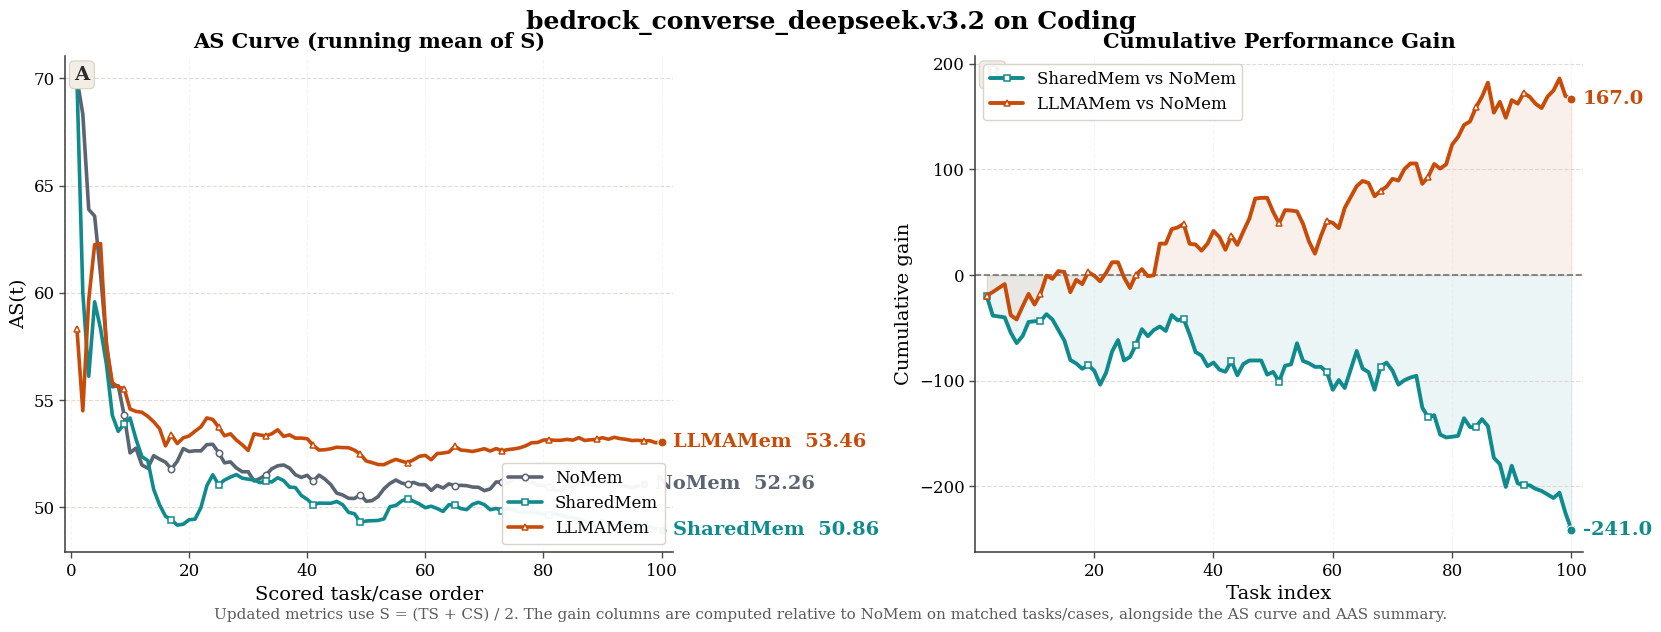


Model: bedrock_converse_qwen.qwen3-32b-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,97,3,49.24,44.23,46.74,109965.69,50118.31,48.01
1,SharedMem,100,96,4,48.82,44.40,46.61,178197.10,66149.48,46.76
2,LLMAMem,100,94,6,49.68,46.69,48.19,123908.53,43962.49,49.43


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,93,46.54,46.79,0.25,3.43,23.33
1,LLMAMem,91,46.60,48.16,1.57,3.02,142.67


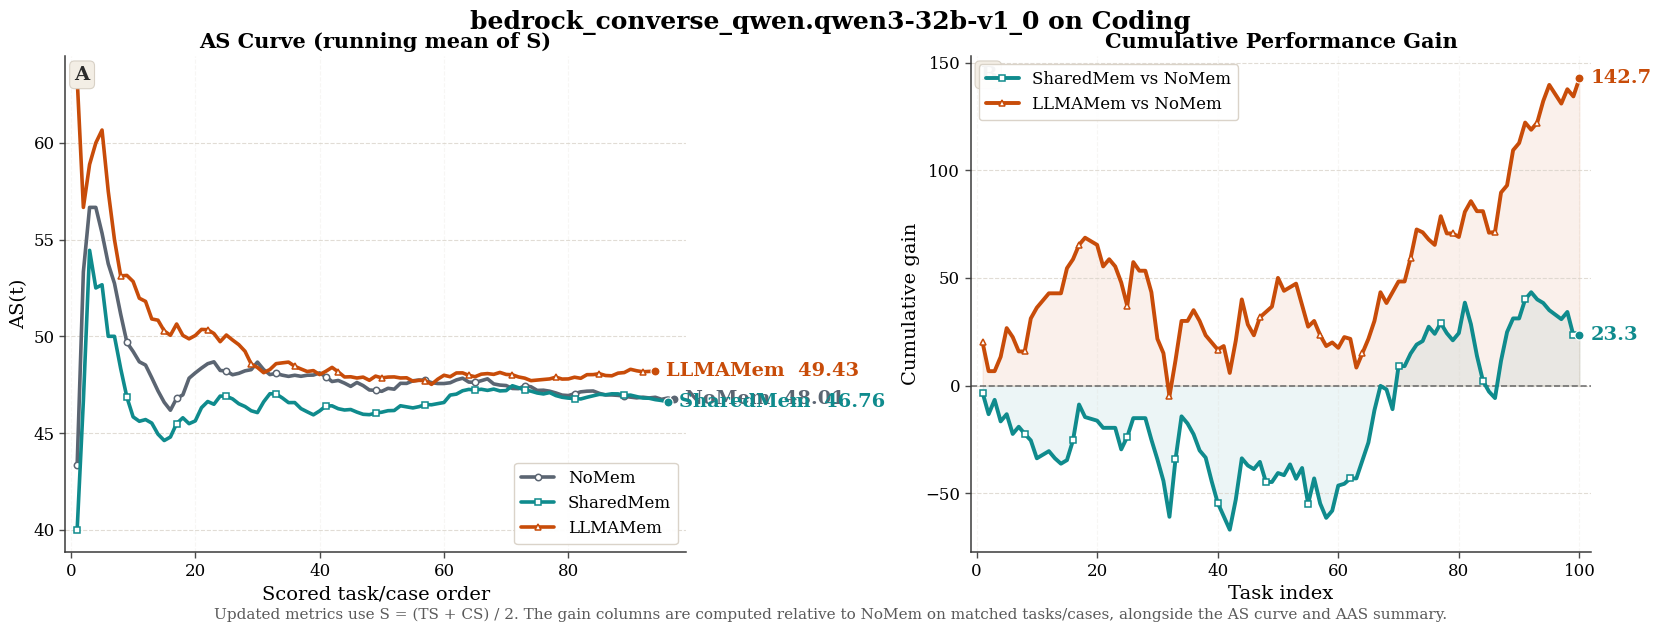


Model: bedrock_converse_qwen.qwen3-next-80b-a3b


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,100,0,58.98,45.20,52.09,213921.84,48071.01,52.85
1,SharedMem,100,97,3,57.03,46.63,51.83,481284.35,95703.14,52.17
2,LLMAMem,100,97,3,60.65,44.86,52.76,217884.48,51896.04,53.12


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,97,51.81,51.83,0.02,3.94,2.17
1,LLMAMem,97,52.05,52.76,0.71,3.67,68.67


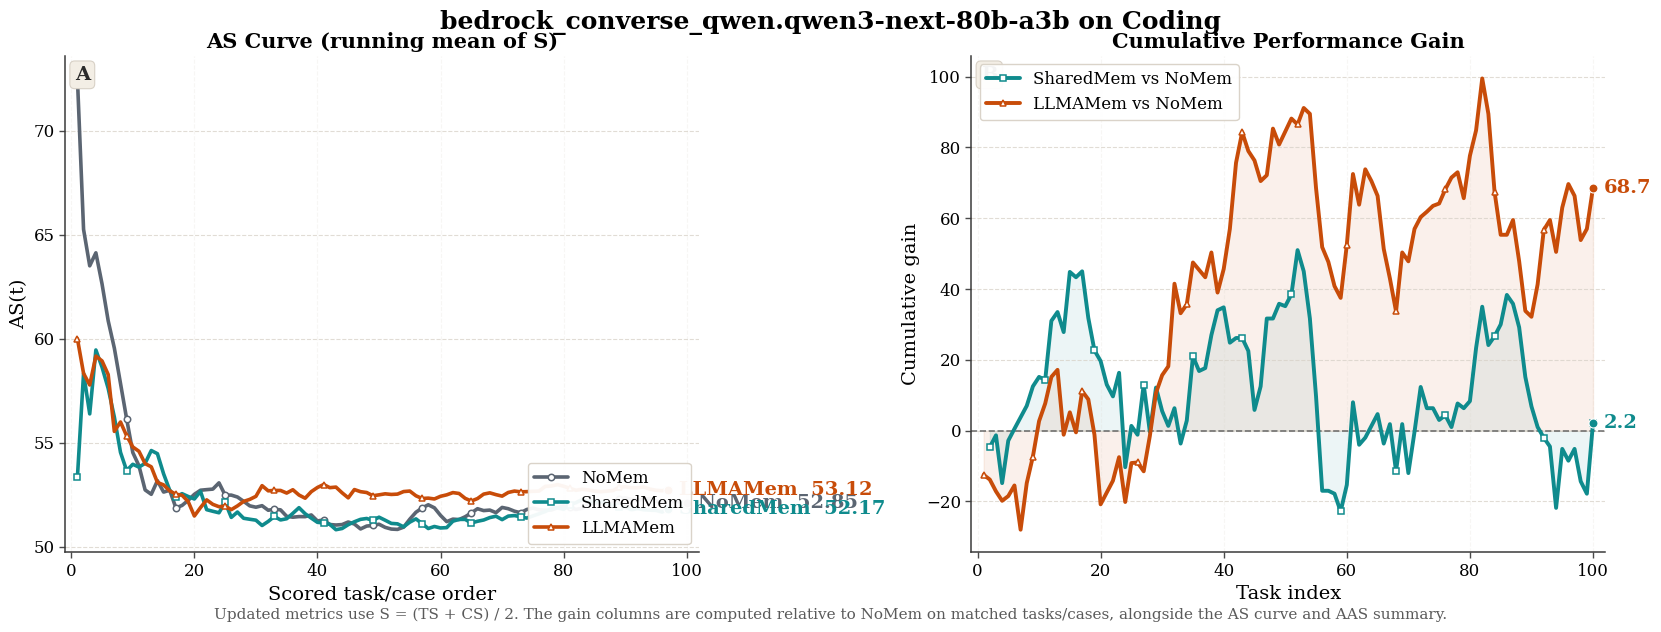


Model: bedrock_converse_us.anthropic.claude-sonnet-4-5-20250929-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,100,0,64.43,42.29,53.36,233629.10,54013.48,53.42
1,SharedMem,100,99,1,63.05,44.71,53.88,382972.69,32648.78,53.99
2,LLMAMem,100,100,0,65.00,44.75,54.88,200060.58,46106.22,54.02


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,98,53.39,53.85,0.46,2.36,44.67
1,LLMAMem,99,53.36,54.96,1.60,2.61,158.33


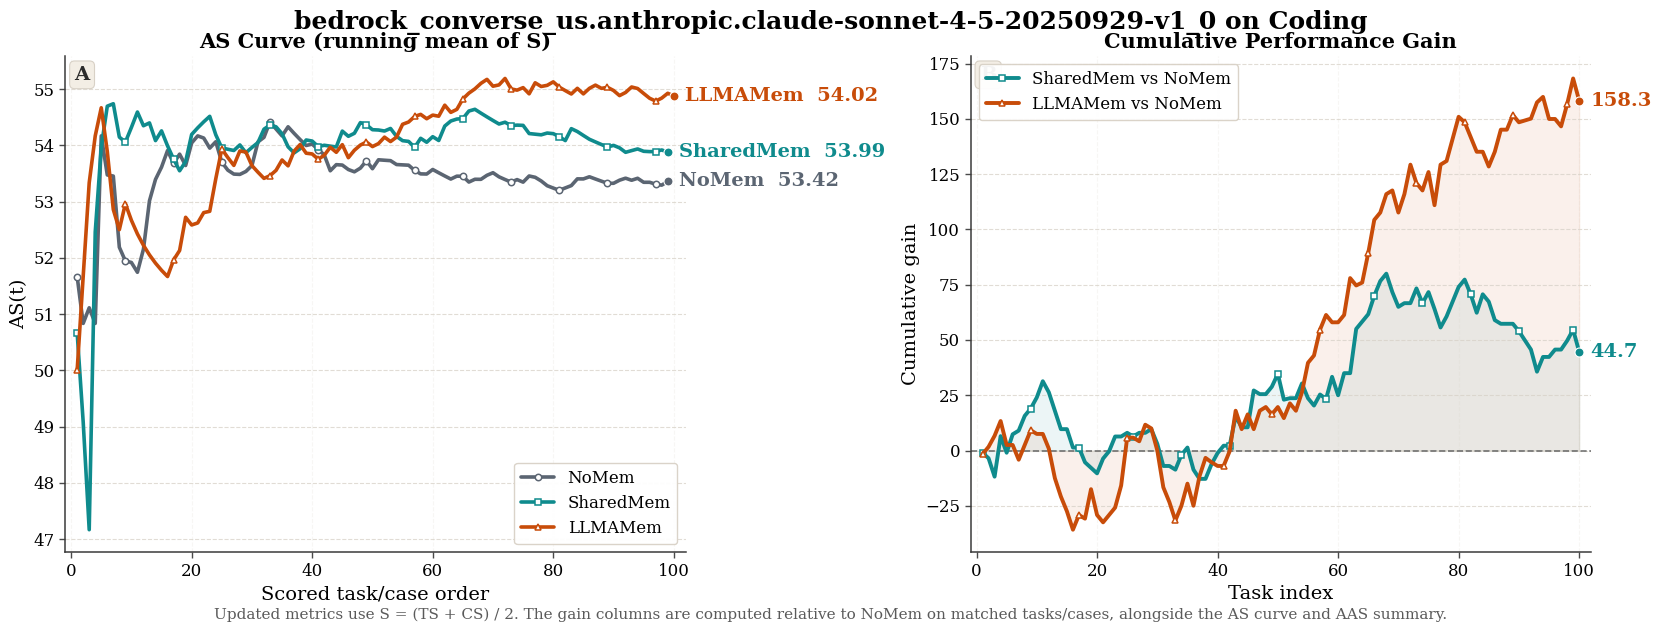


Environment: research

Model: bedrock_converse_deepseek.v3.2


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,94,6,75.53,58.46,66.99,31828.94,2176.51,65.94
1,SharedMem,100,92,8,76.30,58.21,67.26,39173.87,2763.00,68.43
2,LLMAMem,100,98,2,75.10,65.63,70.37,121267.66,8209.61,71.86


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,90,67.38,67.20,-0.18,2.16,-16.50
1,LLMAMem,92,67.04,70.54,3.50,2.84,321.83


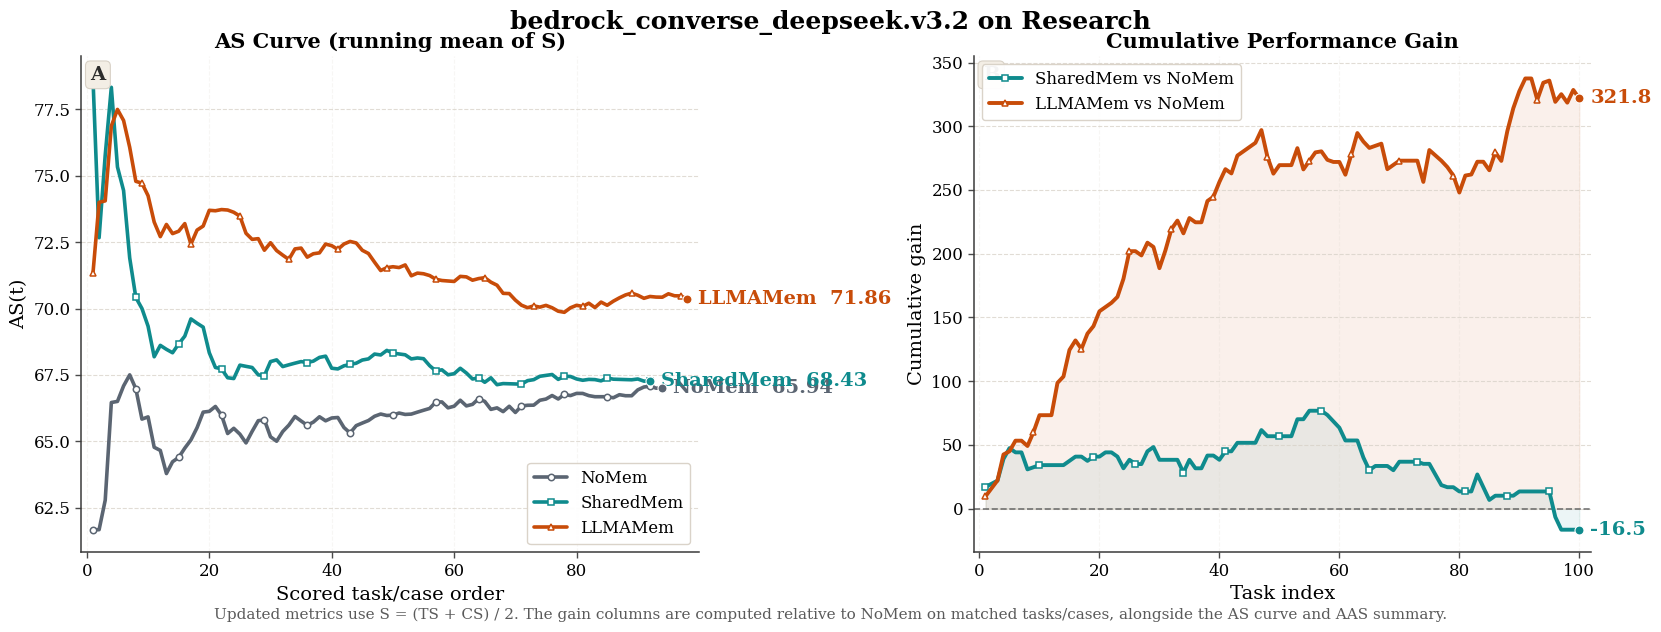


Model: bedrock_converse_qwen.qwen3-32b-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,90,10,71.56,72.63,72.09,132580.34,62270.03,72.06
1,SharedMem,100,91,9,72.38,68.62,70.50,190004.36,71879.79,70.36
2,LLMAMem,97,82,15,73.17,72.89,73.03,59284.22,14744.40,73.30


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,83,71.96,70.52,-1.44,3.96,-119.83
1,LLMAMem,75,72.36,72.62,0.26,3.54,19.67


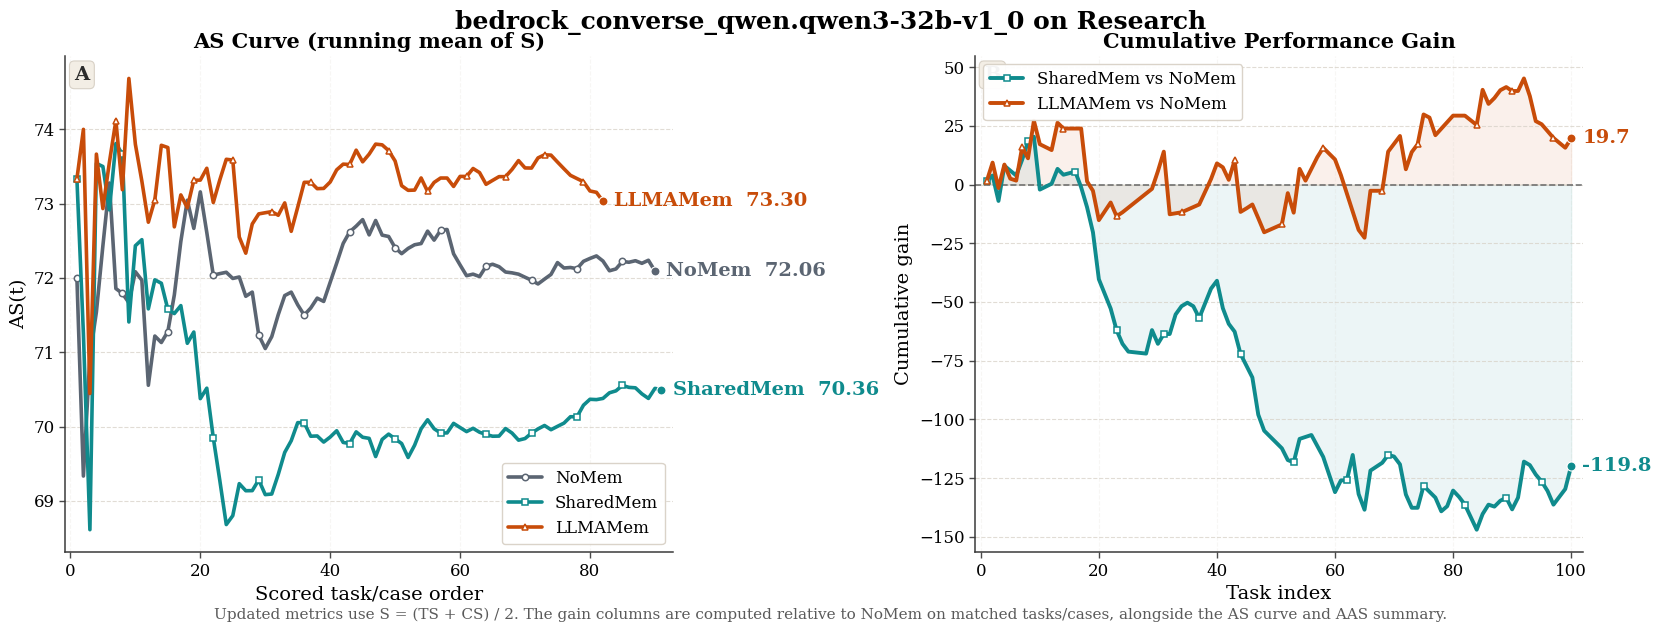


Model: bedrock_converse_qwen.qwen3-next-80b-a3b


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,84,16,57.22,45.52,51.37,91137.61,12863.24,50.13
1,SharedMem,100,74,26,61.62,42.66,52.14,97523.15,11859.64,55.11
2,LLMAMem,98,82,16,67.89,43.62,55.75,82352.48,6327.95,49.54


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,64,52.32,51.07,-1.25,6.50,-80.00
1,LLMAMem,70,50.93,55.40,4.48,4.79,313.33


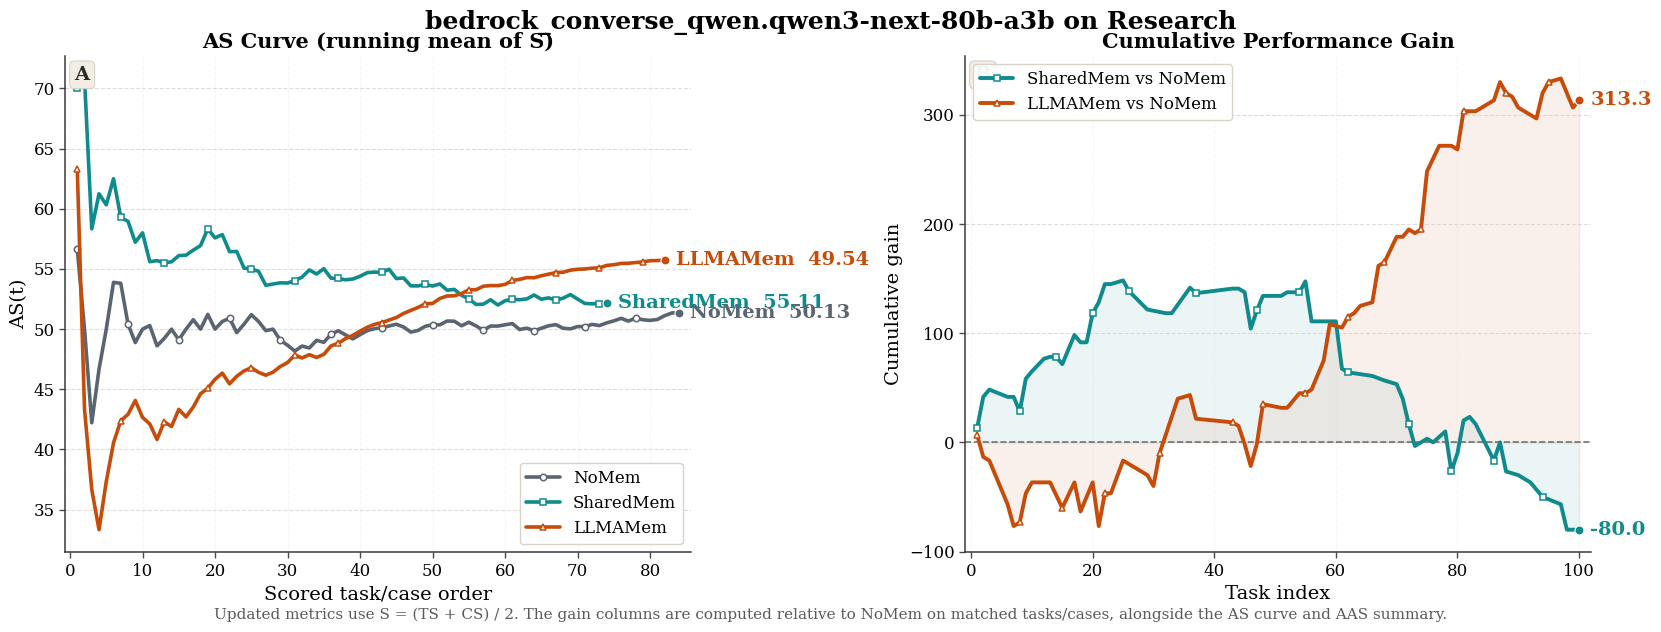


Model: bedrock_converse_us.anthropic.claude-sonnet-4-5-20250929-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,86,14,75.12,78.97,77.04,153863.44,23033.56,76.94
1,SharedMem,100,87,13,75.17,81.84,78.51,256313.52,30572.72,78.37
2,LLMAMem,98,87,11,77.62,74.11,75.87,103787.13,13193.83,77.77


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,76,77.02,77.83,0.81,2.96,61.33
1,LLMAMem,78,76.78,75.81,-0.97,4.98,-76.00


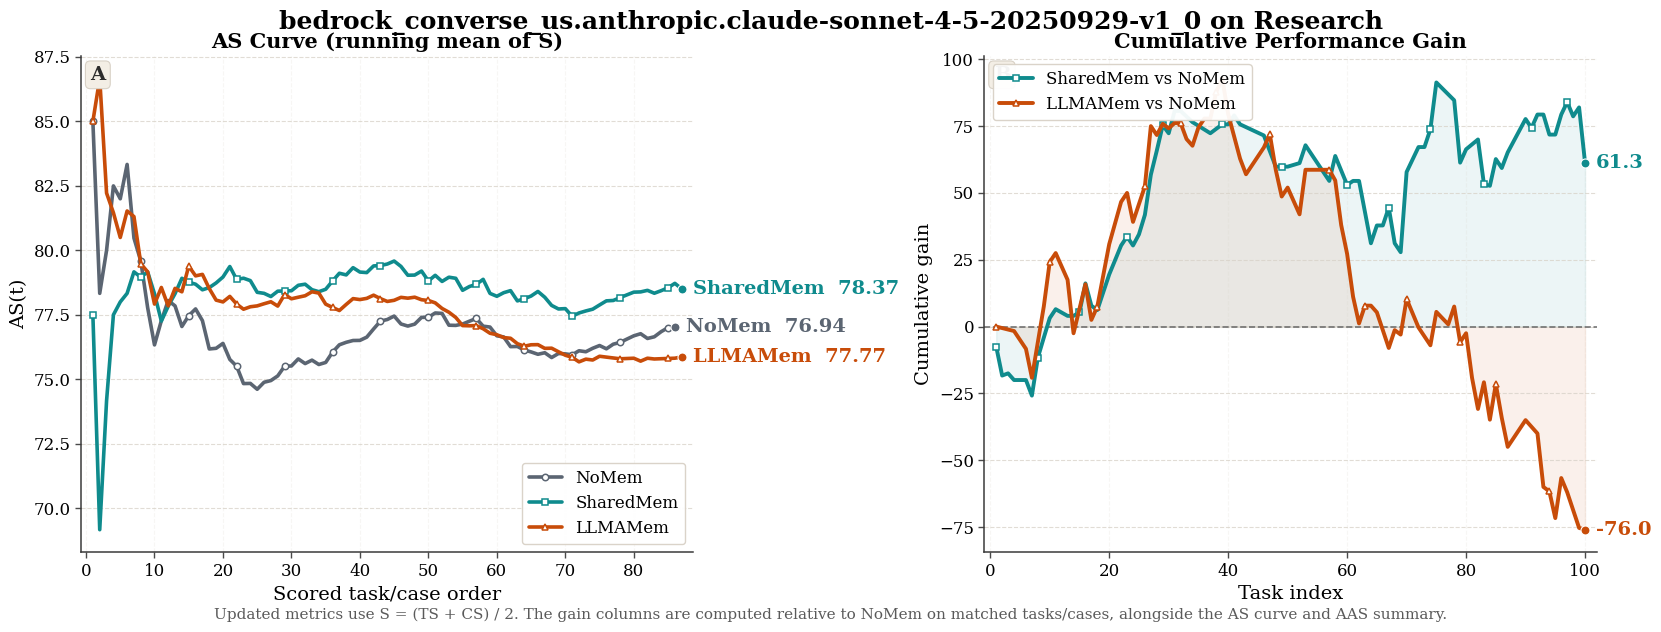


Model: llmamem


""


/tmp/ipykernel_775530/4247072810.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='lower right', ncol=1, fontsize=12)
/tmp/ipykernel_775530/4247072810.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='upper left', ncol=1, fontsize=12)


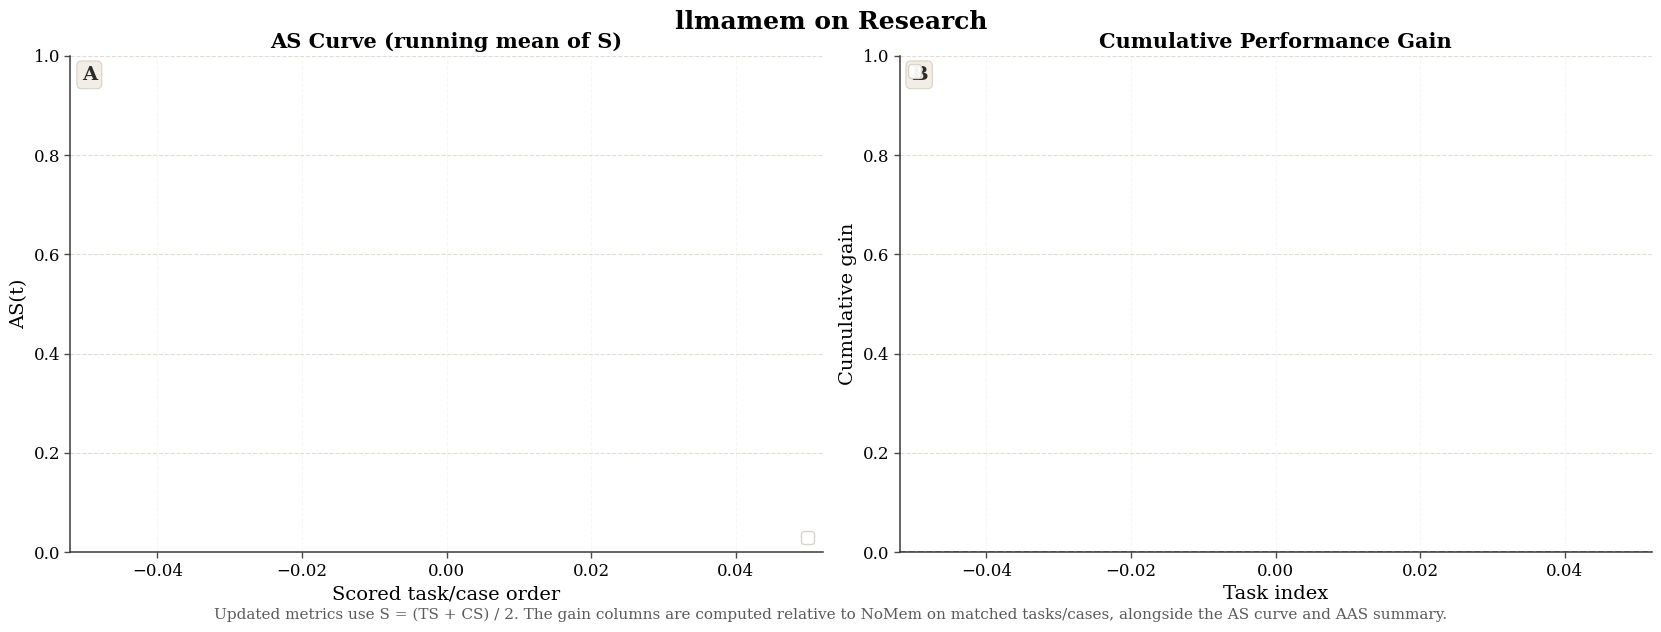


Environment: database

Model: bedrock_converse_deepseek.v3.2


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,100,0,71.0,82.40,76.70,36336.26,6180.78,75.55
1,SharedMem,100,100,0,70.0,75.60,72.80,46171.98,6781.78,72.62
2,LLMAMem,100,100,0,70.0,81.07,75.53,42769.80,6544.98,74.48


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,100,76.7,72.80,-3.90,4.91,-390.00
1,LLMAMem,100,76.7,75.53,-1.17,2.93,-116.67


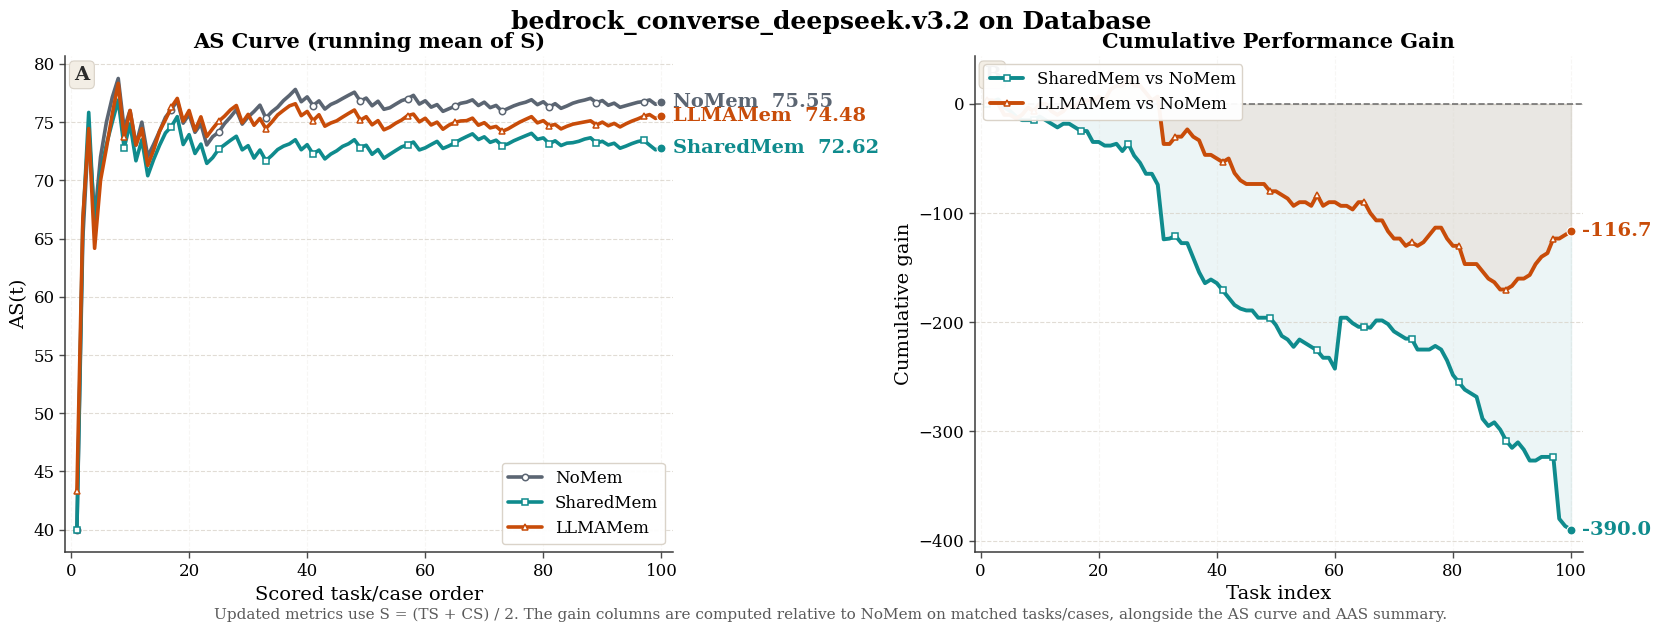


Model: bedrock_converse_qwen.qwen3-32b-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,100,0,71.00,66.07,68.53,39152.51,12754.86,67.87
1,SharedMem,100,100,0,71.72,69.15,70.44,72193.84,34043.64,69.68
2,LLMAMem,99,98,1,70.41,76.18,73.29,48738.60,10525.77,71.06


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,99,68.45,70.44,1.98,6.01,196.5
1,LLMAMem,98,68.71,73.29,4.59,2.02,449.5


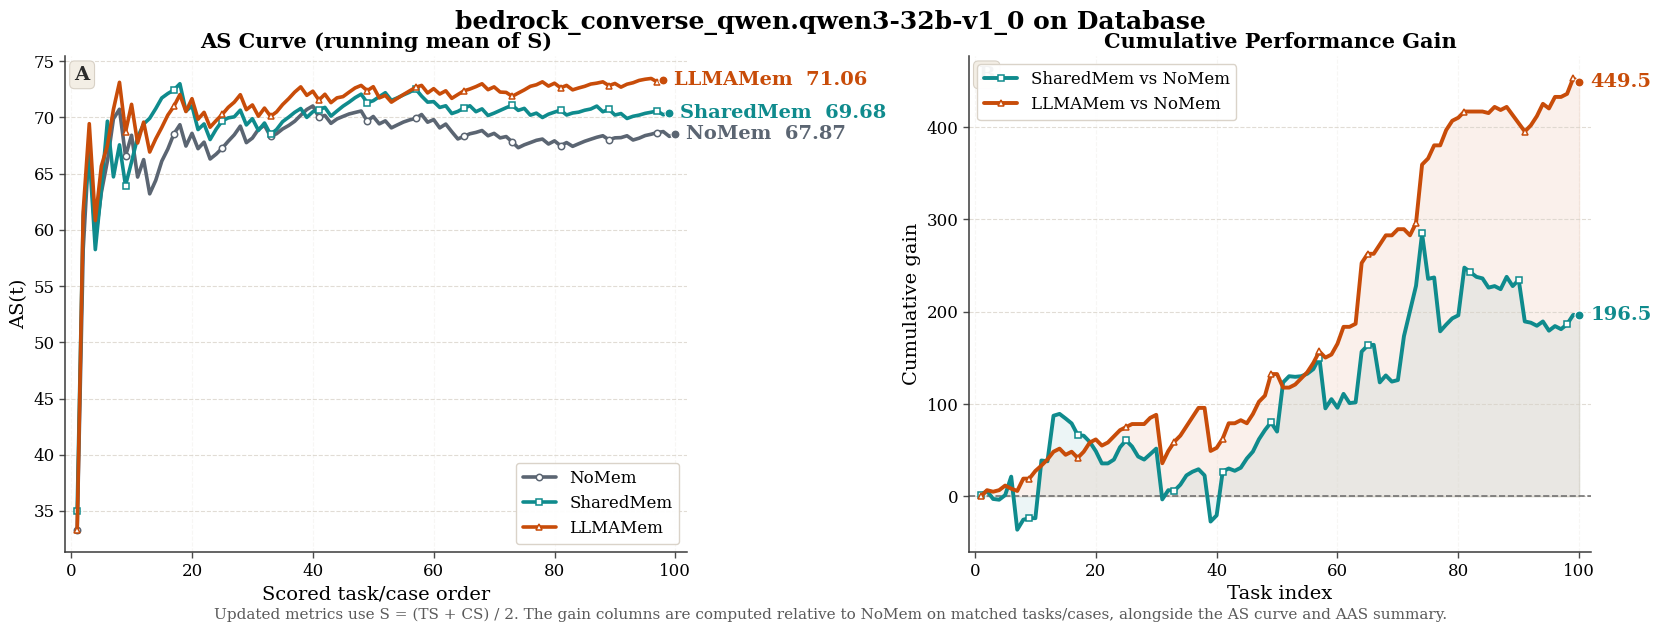


Model: bedrock_converse_qwen.qwen3-next-80b-a3b


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,100,0,69.0,72.32,70.66,37375.91,8576.64,67.61
1,SharedMem,100,100,0,67.0,68.53,67.76,53618.38,9428.68,64.38
2,LLMAMem,100,100,0,70.0,68.55,69.28,48953.94,9720.19,69.98


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,100,70.66,67.76,-2.90,9.92,-289.50
1,LLMAMem,100,70.66,69.28,-1.38,8.19,-138.33


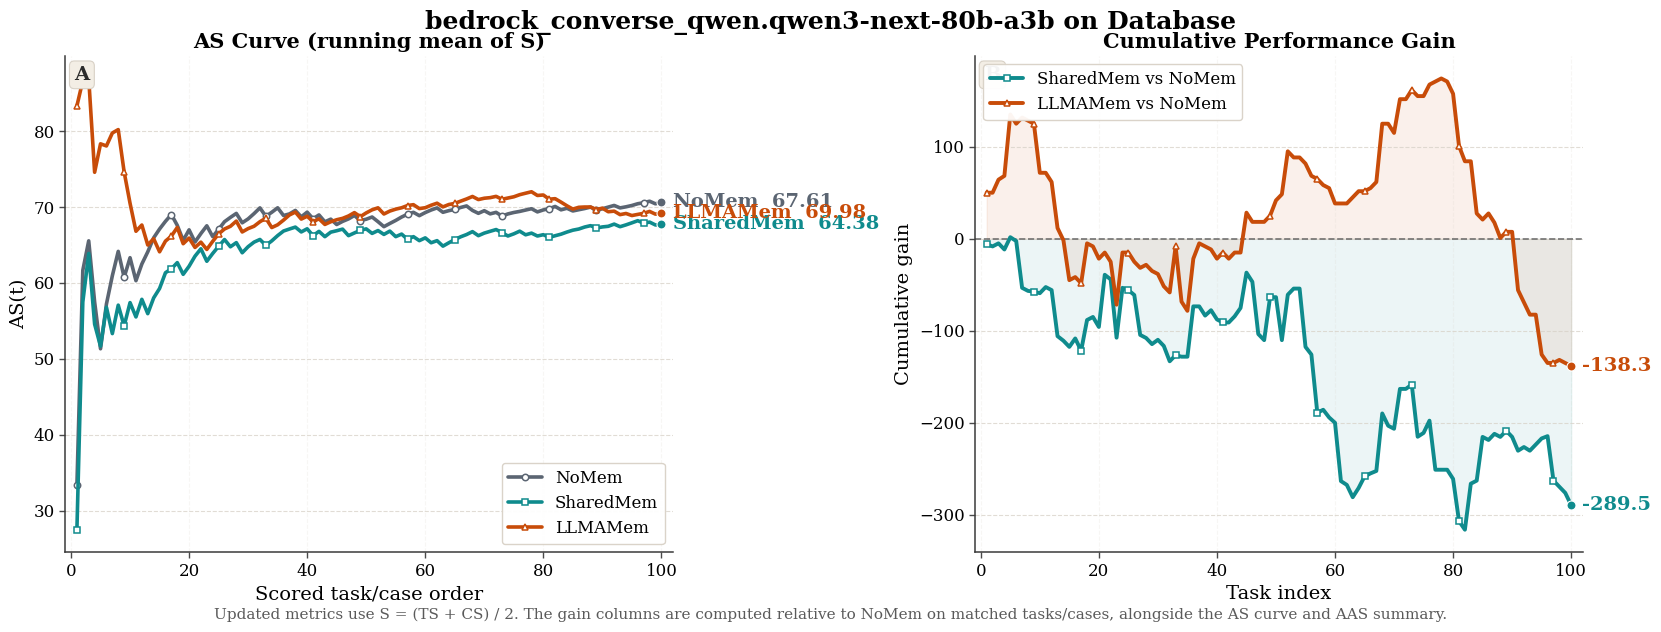


Model: bedrock_converse_us.anthropic.claude-sonnet-4-5-20250929-v1_0


,worker,total,passed,failed,avg_ts,avg_cs,avg_s,avg_input_tokens,avg_output_tokens,aas
0,NoMem,100,99,1,69.39,88.03,78.71,44395.10,9246.12,77.35
1,SharedMem,100,99,1,69.70,82.96,76.33,63574.07,10023.83,75.70
2,LLMAMem,100,100,0,70.00,88.27,79.13,54306.89,9408.11,78.52


,worker,shared_items,diagonal_mean,final_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,SharedMem,97,78.49,76.05,-2.44,3.35,-236.67
1,LLMAMem,98,78.71,78.91,0.20,1.77,20.00


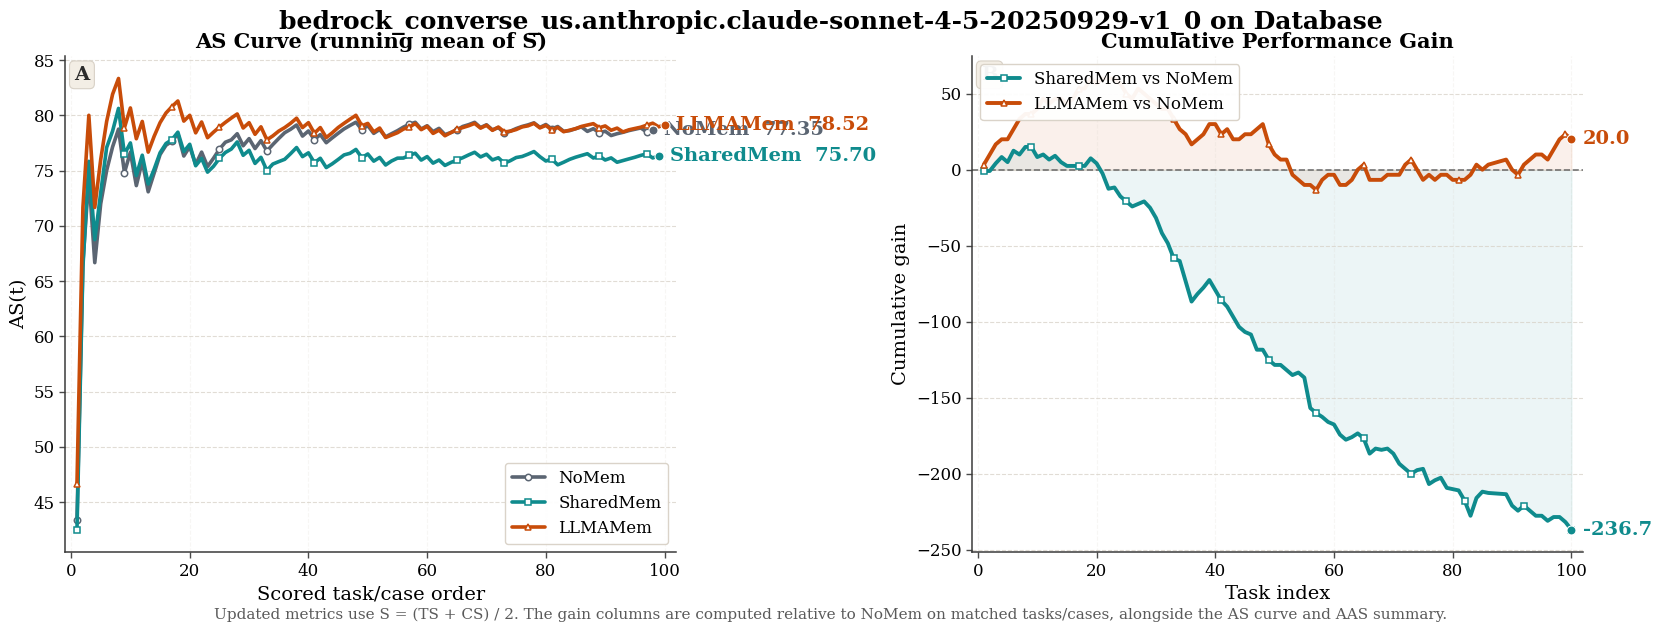

In [28]:
apply_academic_style()

for environment, model_metrics in all_metrics.items():
    print('\n' + '=' * 120)
    print(f'Environment: {environment}')
    print('=' * 120)

    for model_name, worker_metrics in sorted(model_metrics.items()):
        available_workers = [worker for worker in WORKER_ORDER if worker in worker_metrics]
        print(f'\nModel: {model_name}')
        display_table(build_worker_summary_df(worker_metrics))

        gain_model_df = build_gain_df(worker_metrics)
        if table_has_rows(gain_model_df):
            display_table(gain_model_df)

        if plt is None:
            print('matplotlib is not installed in this kernel, so plots are skipped.')
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.8), constrained_layout=True)
        fig.patch.set_facecolor('#ffffff')
        fig.suptitle(
            f'{model_name} on {environment.title()}',
            fontsize=18,
            fontweight='semibold',
            y=1.03,
        )

        for worker in available_workers:
            metrics = worker_metrics[worker]
            x_values = list(range(1, len(metrics['as_y']) + 1))
            axes[0].plot(
                x_values,
                metrics['as_y'],
                label=WORKER_LABELS[worker],
                color=WORKER_COLORS[worker],
                linewidth=2.6,
                marker=WORKER_MARKERS[worker],
                markersize=4.6,
                markerfacecolor='#ffffff',
                markeredgewidth=1.1,
                markevery=max(1, len(x_values) // 12),
                solid_capstyle='round',
                zorder=3,
            )
            annotate_curve_end(
                axes[0],
                x_values,
                metrics['as_y'],
                WORKER_COLORS[worker],
                f"{WORKER_LABELS[worker]}  {metrics['aas']:.2f}" if metrics['aas'] is not None else WORKER_LABELS[worker],
            )

        add_panel_badge(axes[0], 'A')
        axes[0].set_title('AS Curve (running mean of S)', fontsize=15)
        axes[0].set_xlabel('Scored task/case order', fontsize=14)
        axes[0].set_ylabel('AS(t)', fontsize=14)
        style_axis(axes[0])
        axes[0].legend(loc='lower right', ncol=1, fontsize=12)

        if 'nomem' in worker_metrics:
            baseline = worker_metrics['nomem']
            baseline_order = {
                row['id']: row['order']
                for row in baseline['rows']
                if row['s'] is not None
            }
            for worker in ['sharedmem', 'llmamem']:
                if worker not in worker_metrics:
                    continue
                worker_map = worker_metrics[worker]['row_map']
                shared_ids = [
                    item_id for item_id, order in sorted(baseline_order.items(), key=lambda item: item[1])
                    if item_id in worker_map and worker_map[item_id]['s'] is not None
                ]
                cumulative_gain = []
                running_gain = 0.0
                for item_id in shared_ids:
                    running_gain += worker_map[item_id]['s'] - baseline['row_map'][item_id]['s']
                    cumulative_gain.append(running_gain)
                x_values = [baseline['row_map'][item_id]['order'] for item_id in shared_ids]
                axes[1].plot(
                    x_values,
                    cumulative_gain,
                    label=f"{WORKER_LABELS[worker]} vs NoMem",
                    color=WORKER_COLORS[worker],
                    linewidth=2.8,
                    marker=WORKER_MARKERS[worker],
                    markersize=4.6,
                    markerfacecolor='#ffffff',
                    markeredgewidth=1.1,
                    markevery=max(1, len(x_values) // 12),
                    solid_capstyle='round',
                    zorder=3,
                )
                axes[1].fill_between(
                    x_values,
                    cumulative_gain,
                    0,
                    color=WORKER_COLORS[worker],
                    alpha=0.08,
                    zorder=1,
                )
                annotate_curve_end(
                    axes[1],
                    x_values,
                    cumulative_gain,
                    WORKER_COLORS[worker],
                    f"{cumulative_gain[-1]:.1f}" if cumulative_gain else WORKER_LABELS[worker],
                )

        add_panel_badge(axes[1], 'B')
        axes[1].axhline(0.0, color='#666666', linestyle='--', linewidth=1.2, alpha=0.9)
        axes[1].set_title('Cumulative Performance Gain', fontsize=15)
        axes[1].set_xlabel('Task index', fontsize=14)
        axes[1].set_ylabel('Cumulative gain', fontsize=14)
        style_axis(axes[1])
        axes[1].legend(loc='upper left', ncol=1, fontsize=12)

        for ax in axes:
            ax.margins(x=0.02)

        fig.text(
            0.5,
            -0.02,
            'Updated metrics use S = (TS + CS) / 2. The gain columns are computed relative to NoMem on matched tasks/cases, alongside the AS curve and AAS summary.',
            ha='center',
            fontsize=11,
            color='#5a5a5a',
        )

        plt.show()


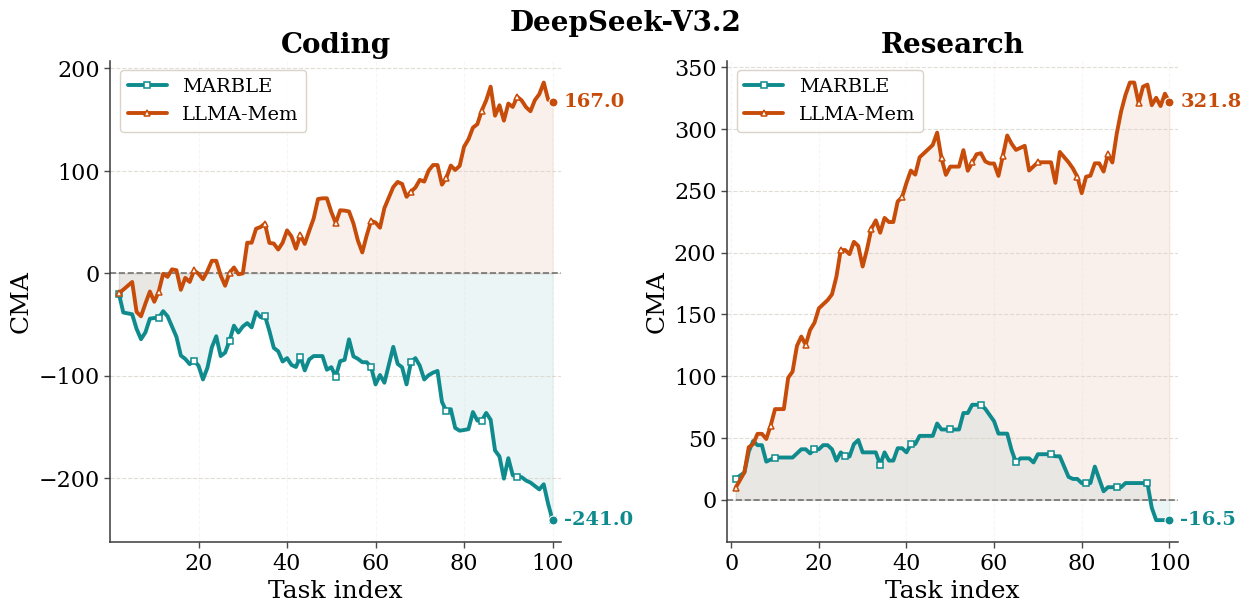

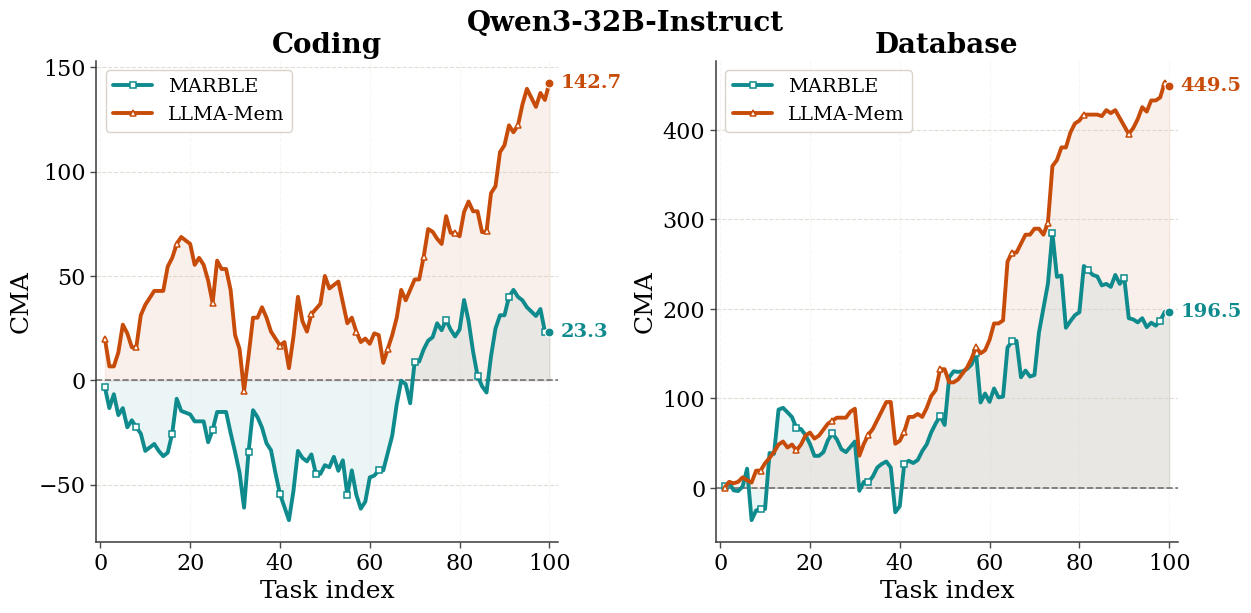

In [29]:
label_dict = {'SharedMem': 'MARBLE', 'LLMAMem': 'LLMA-Mem'}
def plot_cross_environment_cumulative_gain(model_name, figure_title, figure_envs):
    if plt is None:
        print('matplotlib is not installed in this kernel, so plots are skipped.')
        return

    panel_labels = ['A', 'B', 'C', 'D']
    fig, axes = plt.subplots(1, len(figure_envs), figsize=(6.2 * len(figure_envs), 5.8), constrained_layout=True)
    if len(figure_envs) == 1:
        axes = [axes]
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle(figure_title, fontsize=20, fontweight='semibold', y=1.03)

    for ax, environment, panel_label in zip(axes, figure_envs, panel_labels):
        model_metrics = all_metrics.get(environment, {})
        worker_metrics = model_metrics.get(model_name)

        # add_panel_badge(ax, panel_label)
        ax.axhline(0.0, color='#666666', linestyle='--', linewidth=1.2, alpha=0.9)
        ax.set_title(environment.title(), fontsize=20)
        ax.set_xlabel('Task index', fontsize=18)
        ax.set_ylabel('CMA', fontsize=18)

        if not worker_metrics or 'nomem' not in worker_metrics:
            ax.text(0.5, 0.5, 'Not available', transform=ax.transAxes, ha='center', va='center', fontsize=14, color='#6b6b6b')
            style_axis(ax)
            ax.margins(x=0.02)
            continue

        baseline = worker_metrics['nomem']
        baseline_order = {
            row['id']: row['order']
            for row in baseline['rows']
            if row['s'] is not None
        }
        plotted = False

        for worker in ['sharedmem', 'llmamem']:
            if worker not in worker_metrics:
                continue
            worker_map = worker_metrics[worker]['row_map']
            shared_ids = [
                item_id for item_id, order in sorted(baseline_order.items(), key=lambda item: item[1])
                if item_id in worker_map and worker_map[item_id]['s'] is not None
            ]
            cumulative_gain = []
            x_values = []
            running_gain = 0.0
            for item_id in shared_ids:
                running_gain += worker_map[item_id]['s'] - baseline['row_map'][item_id]['s']
                cumulative_gain.append(running_gain)
                x_values.append(baseline['row_map'][item_id]['order'])
            if not cumulative_gain:
                continue

            plotted = True
            ax.plot(
                x_values,
                cumulative_gain,
                label=f"{label_dict.get(WORKER_LABELS[worker], WORKER_LABELS[worker])}",
                color=WORKER_COLORS[worker],
                linewidth=2.8,
                marker=WORKER_MARKERS[worker],
                markersize=4.6,
                markerfacecolor='#ffffff',
                markeredgewidth=1.1,
                markevery=max(1, len(x_values) // 12),
                solid_capstyle='round',
                zorder=3,
            )
            ax.fill_between(
                x_values,
                cumulative_gain,
                0,
                color=WORKER_COLORS[worker],
                alpha=0.08,
                zorder=1,
            )
            annotate_curve_end(
                ax,
                x_values,
                cumulative_gain,
                WORKER_COLORS[worker],
                f"{cumulative_gain[-1]:.1f}",
            )

        if not plotted:
            ax.text(0.5, 0.5, 'No matched tasks', transform=ax.transAxes, ha='center', va='center', fontsize=14, color='#6b6b6b')
        else:
            ax.legend(loc='upper left', ncol=1, fontsize=14)

        style_axis(ax)
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.margins(x=0.02)

    # fig.text(
    #     0.5,
    #     -0.02,
    #     'Cumulative gain is computed against the NoMem baseline on matched tasks. The x-axis uses each task index from the baseline sequence.',
    #     ha='center',
    #     fontsize=9,
    #     color='#5a5a5a',
    # )
    plt.show()

plot_cross_environment_cumulative_gain(
    'bedrock_converse_deepseek.v3.2',
    'DeepSeek-V3.2',
    ['coding', 'research'],
)

plot_cross_environment_cumulative_gain(
    'bedrock_converse_qwen.qwen3-32b-v1_0',
    'Qwen3-32B-Instruct',
    ['coding', 'database'],
)


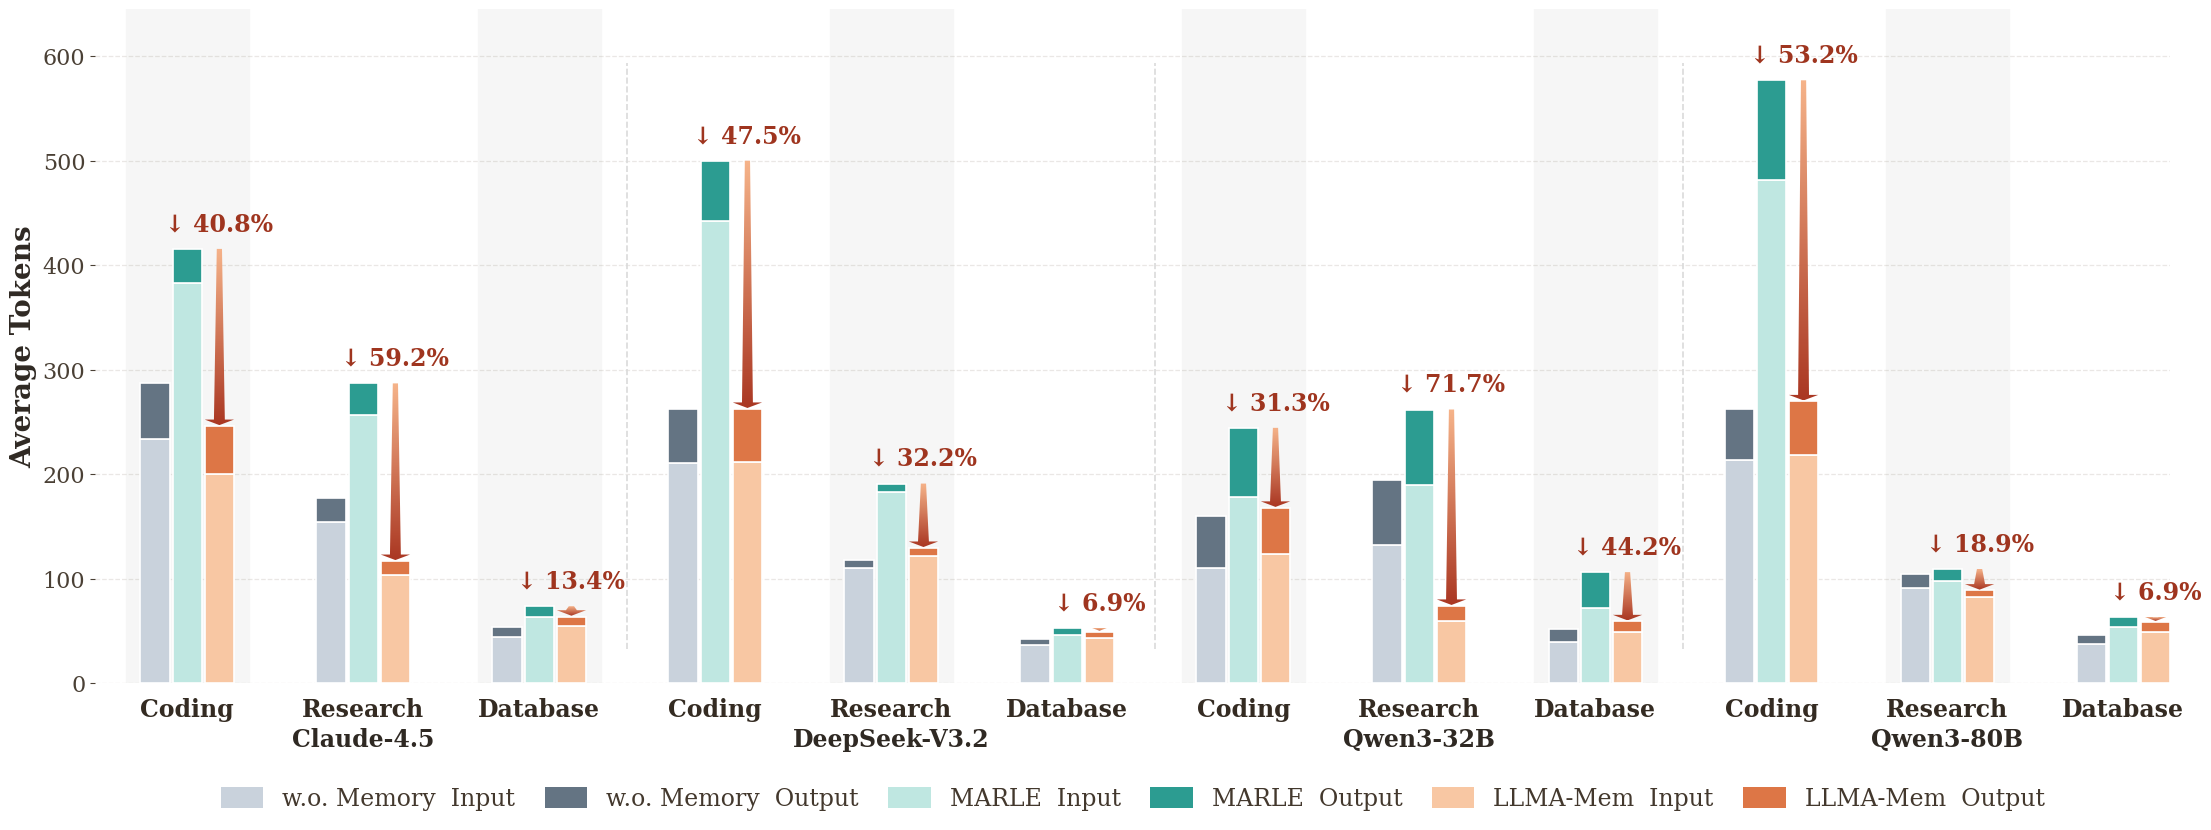

In [42]:
def short_model_name(model_name):
    mapping = {
        'bedrock_converse_deepseek.v3.2': 'DeepSeek-V3.2',
        'bedrock_converse_qwen.qwen3-32b-v1_0': 'Qwen3-32B',
        'bedrock_converse_qwen.qwen3-next-80b-a3b': 'Qwen3-80B',
        'bedrock_converse_us.anthropic.claude-sonnet-4-5-20250929-v1_0': 'Claude-4.5',
    }
    return mapping.get(model_name, model_name)


def human_tokens(value):
    if value is None:
        return 'NA'
    if value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.2f}B"
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    if value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:.0f}"


cost_rows = []
cost_overrides = {
    ('research', 'bedrock_converse_deepseek.v3.2', 'nomem'): {
        'avg_input_tokens': 110_200,
        'avg_output_tokens': 8_100,
    },
    ('research', 'bedrock_converse_deepseek.v3.2', 'sharedmem'): {
        'avg_input_tokens': 183_100,
        'avg_output_tokens': 7_900,
    },
}
for environment, model_metrics in all_metrics.items():
    for model_name, worker_metrics in sorted(model_metrics.items()):
        for worker in [worker for worker in WORKER_ORDER if worker in worker_metrics]:
            metrics = worker_metrics[worker]
            rows = metrics['rows']
            total_input_tokens = sum(row['input_tokens'] for row in rows if row['input_tokens'] is not None)
            total_output_tokens = sum(row['output_tokens'] for row in rows if row['output_tokens'] is not None)
            override = cost_overrides.get((environment, model_name, worker))
            avg_input_tokens = override['avg_input_tokens'] if override else metrics['avg_input_tokens']
            avg_output_tokens = override['avg_output_tokens'] if override else metrics['avg_output_tokens']
            total_tokens = total_input_tokens + total_output_tokens
            avg_total_tokens = (avg_input_tokens + avg_output_tokens) if avg_input_tokens is not None and avg_output_tokens is not None else None
            cost_rows.append({
                'environment': environment,
                'environment_short': environment.title(),
                'model': model_name,
                'model_short': short_model_name(model_name),
                'worker_key': worker,
                'worker': WORKER_LABELS[worker],
                'avg_s': metrics['avg_s'],
                'avg_input_tokens': avg_input_tokens,
                'avg_output_tokens': avg_output_tokens,
                'avg_total_tokens': avg_total_tokens,
                'total_input_tokens': total_input_tokens,
                'total_output_tokens': total_output_tokens,
                'total_tokens': total_tokens,
            })


def pick_rows(rows, **conditions):
    return [
        row for row in rows
        if all(row.get(key) == value for key, value in conditions.items())
    ]


if plt is None:
    print('matplotlib is not installed in this kernel, so the cost figure is skipped.')
else:
    apply_academic_style()

    method_order = ['nomem', 'sharedmem', 'llmamem']
    method_labels = {
        'nomem': 'w.o. Memory',
        'sharedmem': 'MARLE',
        'llmamem': 'LLMA-Mem',
    }
    method_colors = {
        'nomem': {'input': '#C9D2DC', 'output': '#647483'},
        'sharedmem': {'input': '#BFE7E1', 'output': '#2C9C91'},
        'llmamem': {'input': '#F8C7A3', 'output': '#DD7646'},
    }

    available_models = [
        model_name
        for model_name in sorted({row['model'] for row in cost_rows}, key=short_model_name)
        if all(pick_rows(cost_rows, model=model_name, environment=env) for env in ENVIRONMENTS)
    ]
    pair_order = [
        (model_name, environment)
        for model_name in available_models
        for environment in ENVIRONMENTS
    ]

    fig, ax = plt.subplots(figsize=(22, 8.2), constrained_layout=True)
    fig.patch.set_facecolor('#FFFFFF')
    ax.set_facecolor('#FFFFFF')
    for spine in ax.spines.values():
        spine.set_visible(False)

    pair_gap = 0.72
    bar_width = 0.62
    method_offsets = {
        'nomem': -0.68,
        'sharedmem': 0.0,
        'llmamem': 0.68,
    }

    x_pair_centers = []
    x_positions = {}
    for pair_index, pair in enumerate(pair_order):
        pair_center = pair_index * (len(method_order) + pair_gap)
        x_pair_centers.append(pair_center)
        for worker_key in method_order:
            x_positions[(pair, worker_key)] = pair_center + method_offsets[worker_key]

    y_max = 0.0
    marle_to_llmamem_deltas = []

    for pair_index, (model_name, environment) in enumerate(pair_order):
        if pair_index % 2 == 0:
            left = x_pair_centers[pair_index] - 1.30
            right = x_pair_centers[pair_index] + 1.30
            ax.axvspan(left, right, color='#F6F6F6', alpha=1.0, zorder=0)

        for worker_key in method_order:
            matches = pick_rows(cost_rows, model=model_name, environment=environment, worker_key=worker_key)
            if not matches:
                continue
            row = matches[0]
            x = x_positions[((model_name, environment), worker_key)]
            input_k = (row['avg_input_tokens'] or 0.0) / 1000.0
            output_k = (row['avg_output_tokens'] or 0.0) / 1000.0
            total_k = input_k + output_k
            y_max = max(y_max, total_k)

            ax.bar(
                x,
                input_k,
                width=bar_width,
                color=method_colors[worker_key]['input'],
                edgecolor='#FFFFFF',
                linewidth=1.2,
                zorder=3,
            )
            ax.bar(
                x,
                output_k,
                width=bar_width,
                bottom=input_k,
                color=method_colors[worker_key]['output'],
                edgecolor='#FFFFFF',
                linewidth=1.2,
                zorder=4,
            )

        marle_row = pick_rows(cost_rows, model=model_name, environment=environment, worker_key='sharedmem')
        llmamem_row = pick_rows(cost_rows, model=model_name, environment=environment, worker_key='llmamem')
        if marle_row and llmamem_row:
            marle_total = ((marle_row[0]['avg_input_tokens'] or 0.0) + (marle_row[0]['avg_output_tokens'] or 0.0)) / 1000.0
            llmamem_total = ((llmamem_row[0]['avg_input_tokens'] or 0.0) + (llmamem_row[0]['avg_output_tokens'] or 0.0)) / 1000.0
            if marle_total > 0:
                marle_to_llmamem_deltas.append((model_name, environment, marle_total, llmamem_total))
                y_max = max(y_max, marle_total)

    arrow_pad = max(8.0, y_max * 0.065)
    text_pad = max(3.2, y_max * 0.022)

    def draw_gradient_down_arrow(ax, x, y_top, y_bottom, top_color='#F6B287', bottom_color='#A8321D'):
        import numpy as np
        from matplotlib.colors import LinearSegmentedColormap
        from matplotlib.patches import Polygon

        head_height = 5.3
        shaft_top = y_top
        shaft_bottom = y_bottom + head_height
        shaft_width_top = 0.055
        shaft_width_bottom = 0.115
        head_half_width = 0.31

        arrow_shape = Polygon(
            [
                (x - shaft_width_top, shaft_top),
                (x + shaft_width_top, shaft_top),
                (x + shaft_width_bottom, shaft_bottom),
                (x + head_half_width, shaft_bottom),
                (x, y_bottom),
                (x - head_half_width, shaft_bottom),
                (x - shaft_width_bottom, shaft_bottom),
            ],
            closed=True,
            facecolor='none',
            edgecolor='none',
            zorder=6,
        )
        ax.add_patch(arrow_shape)

        gradient = np.linspace(0, 1, 512).reshape(512, 1)
        cmap = LinearSegmentedColormap.from_list('arrow_grad', [top_color, bottom_color])
        image = ax.imshow(
            gradient,
            extent=(x - head_half_width, x + head_half_width, y_bottom, shaft_top),
            origin='upper',
            aspect='auto',
            cmap=cmap,
            interpolation='bicubic',
            zorder=6,
            alpha=0.98,
        )
        image.set_clip_path(arrow_shape)

    for model_name, environment, marle_total, llmamem_total in marle_to_llmamem_deltas:
        llmamem_x = x_positions[((model_name, environment), 'llmamem')]
        percent_drop = (marle_total - llmamem_total) / marle_total * 100.0
        y_start = marle_total
        y_end = llmamem_total + 0.8

        draw_gradient_down_arrow(ax, llmamem_x, y_start, y_end)
        ax.text(
            llmamem_x,
        max(y_start + text_pad, y_start + 2.8),
            f'↓ {abs(percent_drop):.1f}%',
            ha='center',
            va='bottom',
            fontsize=17,
            color='#9F351F',
            fontweight='bold',
            zorder=7,
        )

    ax.set_xticks(x_pair_centers)
    ax.set_xticklabels(
        [environment.title() for _, environment in pair_order],
        fontsize=17,
        color='#342B22',
        fontweight='semibold',
    )
    ax.tick_params(axis='y', labelsize=16, colors='#4A4035')
    ax.tick_params(axis='x', length=0, pad=10)
    ax.set_ylabel('Average Tokens', fontsize=20, color='#2F2923', fontweight='bold')

    model_span = len(ENVIRONMENTS)
    for model_index, model_name in enumerate(available_models):
        start = model_index * model_span
        end = start + model_span - 1
        center = (x_pair_centers[start] + x_pair_centers[end]) / 2.0
        ax.text(
            center,
            -0.065,
            short_model_name(model_name),
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=17,
            color='#2F2923',
            fontweight='bold',
        )
        if model_index < len(available_models) - 1:
            divider_x = (x_pair_centers[end] + x_pair_centers[end + 1]) / 2.0
            ax.axvline(divider_x, ymin=0.05, ymax=0.92, color='#DADADA', linewidth=1.2, linestyle='--', zorder=1)

    from matplotlib.patches import Patch
    legend_handles = []
    for worker_key in method_order:
        legend_handles.append(
            Patch(
                facecolor=method_colors[worker_key]['input'],
                edgecolor='none',
                label=f"{method_labels[worker_key]}  Input",
            )
        )
        legend_handles.append(
            Patch(
                facecolor=method_colors[worker_key]['output'],
                edgecolor='none',
                label=f"{method_labels[worker_key]}  Output",
            )
        )

    legend = ax.legend(
        handles=legend_handles,
        ncol=6,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.14),
        frameon=False,
        fontsize=17,
        handlelength=1.8,
        handleheight=1.0,
        columnspacing=1.25,
        labelspacing=0.9,
        borderaxespad=0.0,
    )
    for text in legend.get_texts():
        text.set_color('#43382D')

    ax.grid(axis='y', linestyle='--', linewidth=0.9, alpha=0.18, color='#8B7E70')
    ax.set_axisbelow(True)
    ax.set_ylim(0, y_max + arrow_pad + text_pad * 2.4)
    ax.margins(x=0.015)

    plt.show()






In [40]:
def build_baseline_relative_transfer_df(worker_metrics):
    if 'nomem' not in worker_metrics:
        return make_table([])

    baseline = worker_metrics['nomem']
    baseline_s_ids = {
        row['id']: row['order']
        for row in baseline['rows']
        if row['s'] is not None
    }

    rows = []
    for worker in ['sharedmem', 'llmamem']:
        if worker not in worker_metrics:
            continue

        worker_map = worker_metrics[worker]['row_map']
        shared_ids = [
            item_id for item_id, order in sorted(baseline_s_ids.items(), key=lambda item: item[1])
            if item_id in worker_map and worker_map[item_id]['s'] is not None
        ]

        if not shared_ids:
            rows.append({
                'worker': WORKER_LABELS[worker],
                'shared_items': 0,
                'nomem_mean': None,
                'method_mean': None,
                'baseline_relative_transfer_end': None,
                'baseline_relative_deficit_end': None,
                'final_cumulative_gain': None,
            })
            continue

        baseline_values = [baseline['row_map'][item_id]['s'] for item_id in shared_ids]
        final_values = [worker_map[item_id]['s'] for item_id in shared_ids]
        deltas = [final_value - baseline_value for baseline_value, final_value in zip(baseline_values, final_values)]

        rows.append({
            'worker': WORKER_LABELS[worker],
            'shared_items': len(shared_ids),
            'nomem_mean': fmt(mean(baseline_values)),
            'method_mean': fmt(mean(final_values)),
            'baseline_relative_transfer_end': fmt(mean(deltas)),
            'baseline_relative_deficit_end': fmt(mean(max(0.0, baseline_value - final_value) for baseline_value, final_value in zip(baseline_values, final_values))),
            'final_cumulative_gain': fmt(sum(deltas)),
        })

    return make_table(rows)

def explain_bwt_fgt_definition():
    print('Definition review for AS / AAS / CMA')
    print('-' * 80)
    print('This notebook uses sequential-evaluation metrics built around S_t, AS(t), AAS, and cumulative gain relative to NoMem.')
    print('')
    print('Standard continual-learning definitions require a performance matrix R where R[t, i] is performance on task i after learning through task t.')
    print('')
    print('AS / AAS definitions:')
    print('  AS(t) = (1 / t) * sum_{i=1}^t S_i')
    print('')
    print('')
    print('  AAS = (1 / T) * sum_{t=1}^T AS(t)')
    print('')
    print('The current outputs store one score per task/case per method, so the notebook tracks sequential performance trends directly instead of classical CL reevaluation metrics.')
    print('')
    print('Cumulative memory advantage against NoMem is defined as:')
    print('  CMA_t = sum_{i=1}^t ( S_method(i) - S_NoMem(i) )')
    print('')

explain_bwt_fgt_definition()

baseline_relative_frames = []
for environment, model_metrics in all_metrics.items():
    for model_name, worker_metrics in sorted(model_metrics.items()):
        rel_df = build_baseline_relative_transfer_df(worker_metrics)
        if table_has_rows(rel_df):
            rel_df = prepend_columns(rel_df, {'environment': environment, 'model': model_name})
            baseline_relative_frames.append(rel_df)

baseline_relative_summary_df = concat_tables(baseline_relative_frames)
print('')
print('Cumulative performance gain table')
display_table(baseline_relative_summary_df)


Definition review for AS / AAS / CMA
--------------------------------------------------------------------------------
This notebook uses sequential-evaluation metrics built around S_t, AS(t), AAS, and cumulative gain relative to NoMem.

Standard continual-learning definitions require a performance matrix R where R[t, i] is performance on task i after learning through task t.

AS / AAS definitions:
  AS(t) = (1 / t) * sum_{i=1}^t S_i


  AAS = (1 / T) * sum_{t=1}^T AS(t)

The current outputs store one score per task/case per method, so the notebook tracks sequential performance trends directly instead of classical CL reevaluation metrics.

Cumulative memory advantage against NoMem is defined as:
  CMA_t = sum_{i=1}^t ( S_method(i) - S_NoMem(i) )


Cumulative performance gain table


,environment,model,worker,shared_items,nomem_mean,method_mean,baseline_relative_transfer_end,baseline_relative_deficit_end,final_cumulative_gain
0,coding,bedrock_converse_deepseek.v3.2,SharedMem,97,51.08,48.60,-2.48,5.84,-241.00
1,coding,bedrock_converse_deepseek.v3.2,LLMAMem,97,51.08,52.80,1.72,3.85,167.00
2,coding,bedrock_converse_qwen.qwen3-32b-v1_0,SharedMem,93,46.54,46.79,0.25,3.43,23.33
3,coding,bedrock_converse_qwen.qwen3-32b-v1_0,LLMAMem,91,46.60,48.16,1.57,3.02,142.67
4,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,SharedMem,97,51.81,51.83,0.02,3.94,2.17
5,coding,bedrock_converse_qwen.qwen3-next-80b-a3b,LLMAMem,97,52.05,52.76,0.71,3.67,68.67
6,coding,bedrock_converse_us.anthropic.claude-sonnet-4-...,SharedMem,98,53.39,53.85,0.46,2.36,44.67
7,coding,bedrock_converse_us.anthropic.claude-sonnet-4-...,LLMAMem,99,53.36,54.96,1.60,2.61,158.33
8,research,bedrock_converse_deepseek.v3.2,SharedMem,90,67.38,67.20,-0.18,2.16,-16.50
9,research,bedrock_converse_deepseek.v3.2,LLMAMem,92,67.04,70.54,3.50,2.84,321.83


In [ ]:
TEAM_SIZE_MODELS = [
    'bedrock_converse_deepseek.v3.2',
    'bedrock_converse_qwen.qwen3-32b-v1_0',
    'bedrock_converse_qwen.qwen3-next-80b-a3b',
    'bedrock_converse_us.anthropic.claude-sonnet-4-5-20250929-v1_0',
]
TEAM_SIZE_RUN_TAG_PREFIX = 'llmamem_common16'
TEAM_SIZE_VALUES = [1, 3, 5, 7]
TEAM_SIZE_TARGET_POINTS = 16

try:
    import numpy as np
except ImportError:
    np = None

if plt is None or np is None:
    print('matplotlib and numpy are required for the team-size plots.')
else:
    apply_academic_style()

    def load_team_size_rows(model_name, team_size, run_tag_prefix):
        run_dir = result_root / 'research' / model_name / 'llmamem' / f'{run_tag_prefix}_team{team_size}'
        if not run_dir.exists():
            return None

        task_paths = sorted(
            run_dir.glob('task_*.jsonl'),
            key=lambda path: int(path.stem.split('_')[1]),
        )
        rows = []
        for task_path in task_paths:
            records = []
            with task_path.open('r', encoding='utf-8') as f:
                for raw in f:
                    raw = raw.strip()
                    if raw:
                        records.append(json.loads(raw))
            if not records:
                continue

            record = records[-1]
            if is_research_failed(record):
                continue

            ts = compute_research_ts(record)
            cs = analyze_output.compute_cs(record)
            if ts is None or cs is None:
                continue

            rows.append({
                'task_id': int(task_path.stem.split('_')[1]),
                'ts': ts,
                'cs': cs,
                's': (ts + cs) / 2.0,
            })

        return rows or None

    def natural_sort_rows(rows):
        indexed_rows = list(enumerate(rows))
        def soft_key(item):
            idx, row = item
            perturb = 0.22 * np.sin(row['task_id'] * 0.9 + idx * 0.7)
            perturb += 0.08 * np.cos((idx + 1) * 1.3)
            return row['s'] + perturb
        return [row for _, row in sorted(indexed_rows, key=soft_key)]

    def build_as_curve(rows, target_points=TEAM_SIZE_TARGET_POINTS):
        ordered_rows = natural_sort_rows(rows)
        ordered_scores = [row['s'] for row in ordered_rows]
        as_y = []
        running_total = 0.0
        for index, score in enumerate(ordered_scores, start=1):
            running_total += score
            as_y.append(running_total / index)

        original_x = np.arange(1, len(as_y) + 1, dtype=float)
        if len(as_y) == 1:
            smooth_x = np.arange(1, target_points + 1, dtype=float)
            smooth_y = np.full(target_points, as_y[0], dtype=float)
        elif len(as_y) < target_points:
            smooth_x = np.linspace(1, target_points, target_points)
            source_x = np.linspace(1, target_points, len(as_y))
            smooth_y = np.interp(smooth_x, source_x, np.array(as_y, dtype=float))
        else:
            smooth_x = original_x
            smooth_y = np.array(as_y, dtype=float)

        return {
            'rows': ordered_rows,
            'original_points': len(as_y),
            'ordered_scores': ordered_scores,
            'as_y': as_y,
            'smooth_x': smooth_x.tolist(),
            'smooth_y': smooth_y.tolist(),
            'aas': float(np.mean(smooth_y)),
            'final_as': float(smooth_y[-1]),
        }

    team_size_all_metrics = {}
    for model_name in TEAM_SIZE_MODELS:
        per_team = {}
        for team_size in TEAM_SIZE_VALUES:
            rows = load_team_size_rows(model_name, team_size, TEAM_SIZE_RUN_TAG_PREFIX)
            if rows:
                per_team[team_size] = build_as_curve(rows)
        team_size_all_metrics[model_name] = per_team

    available_models = [model_name for model_name in TEAM_SIZE_MODELS if team_size_all_metrics.get(model_name)]

    if not available_models:
        print('No team-size result files were found for the selected models.')
    else:
        team_size_colors = {
            1: '#4C566A',
            3: '#2E86AB',
            5: '#2A9D8F',
            7: '#D97706',
        }

        fig, axes = plt.subplots(2, 2, figsize=(16.5, 11.2), constrained_layout=True)
        fig.patch.set_facecolor('#ffffff')
        axes = axes.flatten()

        legend_handles = None
        for ax, model_name in zip(axes, TEAM_SIZE_MODELS):
            ax.set_facecolor('#ffffff')
            style_axis(ax)
            metrics_by_size = team_size_all_metrics.get(model_name, {})
            available_team_sizes = [team_size for team_size in TEAM_SIZE_VALUES if team_size in metrics_by_size]

            for team_size in available_team_sizes:
                metrics = metrics_by_size[team_size]
                line, = ax.plot(
                    metrics['smooth_x'],
                    metrics['smooth_y'],
                    label=f'{team_size} agents',
                    color=team_size_colors.get(team_size, '#333333'),
                    linewidth=3.0,
                    solid_capstyle='round',
                    solid_joinstyle='round',
                    zorder=3,
                )
                if legend_handles is None:
                    legend_handles = []
                if len(legend_handles) < len(available_team_sizes):
                    legend_handles.append(line)

            ax.set_title(short_model_name(model_name), fontsize=17, fontweight='bold', pad=10)
            ax.set_xlabel('Task Order', fontsize=15)
            ax.set_ylabel('AS(t)', fontsize=15)
            ax.tick_params(axis='both', labelsize=13)
            ax.set_xlim(1, TEAM_SIZE_TARGET_POINTS)

            if not available_team_sizes:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center', fontsize=15, color='#7A6F63')

        for ax in axes[len(TEAM_SIZE_MODELS):]:
            ax.axis('off')

        if legend_handles:
            fig.legend(
                legend_handles,
                [handle.get_label() for handle in legend_handles],
                loc='lower center',
                ncol=4,
                frameon=False,
                fontsize=15,
                bbox_to_anchor=(0.5, -0.01),
            )
        plt.show()

        summary_rows = []
        detailed_rows = []
        for model_name in available_models:
            for team_size in TEAM_SIZE_VALUES:
                metrics = team_size_all_metrics[model_name].get(team_size)
                if not metrics:
                    continue
                summary_rows.append({
                    'model': short_model_name(model_name),
                    'team_size': team_size,
                    'scored_tasks': metrics['original_points'],
                    'aas': metrics['aas'],
                    'final_as': metrics['final_as'],
                    'avg_s': sum(row['s'] for row in metrics['rows']) / len(metrics['rows']) if metrics['rows'] else None,
                    'avg_ts': sum(row['ts'] for row in metrics['rows']) / len(metrics['rows']) if metrics['rows'] else None,
                    'avg_cs': sum(row['cs'] for row in metrics['rows']) / len(metrics['rows']) if metrics['rows'] else None,
                })
                for order_index, row in enumerate(metrics['rows'], start=1):
                    detailed_rows.append({
                        'model': short_model_name(model_name),
                        'team_size': team_size,
                        'sorted_order': order_index,
                        'task_id': row['task_id'],
                        'ts': row['ts'],
                        'cs': row['cs'],
                        's': row['s'],
                    })

        display_table(make_table(summary_rows))
        print('TS, CS, and S=(TS+CS)/2 after naturalized low-to-high sorting')
        display_table(make_table(detailed_rows))



In [ ]:
try:
    import numpy as np
except ImportError:
    np = None

if plt is None or np is None:
    print('matplotlib and numpy are required for the 3D plot.')
else:
    apply_academic_style()

    if 'team_size_all_metrics' not in globals() or not team_size_all_metrics:
        print('Run the team-size curve cell first so team_size_all_metrics is available.')
    else:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

        available_models = [model_name for model_name in TEAM_SIZE_MODELS if team_size_all_metrics.get(model_name)]
        if not available_models:
            print('No team-size metrics available for 3D plotting.')
        else:
            team_size_colors = {
                1: '#4C566A',
                3: '#2E86AB',
                5: '#2A9D8F',
                7: '#D97706',
            }

            fig = plt.figure(figsize=(17.5, 11.5), constrained_layout=True)
            fig.patch.set_facecolor('#ffffff')

            for plot_index, model_name in enumerate(TEAM_SIZE_MODELS, start=1):
                ax = fig.add_subplot(2, 2, plot_index, projection='3d')
                ax.set_facecolor('#ffffff')
                metrics_by_size = team_size_all_metrics.get(model_name, {})
                available_team_sizes = [team_size for team_size in TEAM_SIZE_VALUES if team_size in metrics_by_size]

                if not available_team_sizes:
                    ax.text2D(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center', fontsize=14)
                    ax.set_axis_off()
                    continue

                max_points = max(len(metrics_by_size[team_size]['smooth_y']) for team_size in available_team_sizes)
                x_grid = np.arange(1, max_points + 1, dtype=float)
                y_grid = np.array(sorted(available_team_sizes), dtype=float)
                z_grid = np.full((len(y_grid), len(x_grid)), np.nan, dtype=float)

                for y_index, team_size in enumerate(y_grid.astype(int)):
                    curve = np.array(metrics_by_size[team_size]['smooth_y'], dtype=float)
                    source_x = np.arange(1, len(curve) + 1, dtype=float)
                    if len(curve) == 1:
                        z_grid[y_index, :] = curve[0]
                    else:
                        z_grid[y_index, :] = np.interp(x_grid, source_x, curve, left=curve[0], right=curve[-1])

                dense_x = np.linspace(float(x_grid.min()), float(x_grid.max()), max(140, len(x_grid) * 8))
                dense_y = np.linspace(float(y_grid.min()), float(y_grid.max()), 120)

                interpolated_rows = []
                for column in range(z_grid.shape[1]):
                    interpolated_rows.append(np.interp(dense_y, y_grid, z_grid[:, column]))
                dense_columns = np.vstack(interpolated_rows).T

                dense_z = np.empty((len(dense_y), len(dense_x)), dtype=float)
                for row_index, row in enumerate(dense_columns):
                    dense_z[row_index, :] = np.interp(dense_x, x_grid, row)

                X_dense, Y_dense = np.meshgrid(dense_x, dense_y)

                ax.plot_surface(
                    X_dense,
                    Y_dense,
                    dense_z,
                    cmap='YlGnBu',
                    alpha=0.42,
                    linewidth=0,
                    antialiased=True,
                    shade=True,
                )

                for team_size in available_team_sizes:
                    metrics = metrics_by_size[team_size]
                    x_values = np.array(metrics['smooth_x'], dtype=float)
                    y_values = np.full_like(x_values, float(team_size), dtype=float)
                    z_values = np.array(metrics['smooth_y'], dtype=float)
                    color = team_size_colors.get(team_size, '#333333')

                    ax.plot(
                        x_values,
                        y_values,
                        z_values,
                        color=color,
                        linewidth=3.0,
                        solid_capstyle='round',
                        zorder=5,
                    )

                ax.text2D(0.05, 0.92, short_model_name(model_name), transform=ax.transAxes, fontsize=15, fontweight='bold', color='#2F2923')
                ax.set_xlabel('Task Order', labelpad=10)
                ax.set_ylabel('Team Size', labelpad=10)
                ax.set_zlabel('AS(t)', labelpad=8)
                ax.set_xlim(1, TEAM_SIZE_TARGET_POINTS)
                ax.set_yticks(sorted(available_team_sizes))
                ax.view_init(elev=28, azim=-132)

                ax.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
                ax.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
                ax.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
                ax.xaxis._axinfo['grid']['color'] = (0.84, 0.82, 0.78, 0.35)
                ax.yaxis._axinfo['grid']['color'] = (0.84, 0.82, 0.78, 0.35)
                ax.zaxis._axinfo['grid']['color'] = (0.84, 0.82, 0.78, 0.35)
                ax.tick_params(axis='both', which='major', labelsize=11)

            plt.show()

